# Haemodynamic Phenotyping
## Can We Discover Hidden Blood Pressure Patterns in Surgery?

Every anaesthetist has an intuitive sense that some cases "run smooth" while others are a constant battle with the blood pressure. But have you ever wondered whether there are only a handful of distinct haemodynamic stories that keep repeating across different patients and surgeries?

In this chapter, we tackle a fascinating question: **instead of simply asking "did the blood pressure drop?", we ask "what kind of blood pressure journey did this patient take?"** We will let the data itself reveal recurring patterns — or **phenotypes** — in how mean arterial pressure (MAP) behaves from induction to emergence.

> *"Every case looks different in the moment. But when you look at 100 cases together, patterns emerge — recurring haemodynamic narratives that most clinicians have never seen mapped."*

The technique we use is called **unsupervised clustering** — a branch of machine learning where the computer sorts patients into groups based on how similar their blood pressure trajectories are, *without being told in advance what the groups should be*. Think of it as asking a colleague to sort a stack of arterial line printouts into piles of "cases that look alike" — but doing it mathematically, consistently, and at scale.

### What you will learn

- **What a haemodynamic phenotype is** — a recurring pattern of MAP behaviour across a surgical case, discovered from data rather than defined by a rule
- **How unsupervised clustering works** — the k-means algorithm groups patients by similarity, without needing outcome labels
- **How to read an elbow plot and silhouette score** — simple tools that help us decide how many groups exist in the data
- **What PCA (principal component analysis) does** — a way to compress complex trajectories into a simple 2D picture you can visualise
- **Whether phenotype predicts outcomes** — do patients with "worse-looking" MAP trajectories actually have higher rates of acute kidney injury?
- **Whether we can predict the phenotype early** — can the first 10 minutes of a case tell us what kind of haemodynamic story is coming?

### Clinical motivation

If distinct haemodynamic phenotypes exist and they predict outcomes, this has real implications: we could identify high-risk trajectories early and intervene before harm accumulates. This is the difference between reactive anaesthesia ("the pressure dropped, give a bolus") and anticipatory anaesthesia ("the trajectory suggests this patient is heading for trouble").

---
**Dataset:** 100 surgical cases from the `art_cache/` directory — beat-averaged MAP at 0.5 Hz with AKI outcome labels from VitalDB.

## Setting Up Our Toolkit

Before we dive into the analysis, we need to load the Python libraries that will do the heavy lifting. You do not need to understand every import line — the key tools are:

- **pandas** and **numpy** — for handling tabular data and numerical arrays
- **matplotlib** and **seaborn** — for creating plots and figures
- **scikit-learn** — the machine learning library that provides our clustering algorithm (k-means), our dimensionality reduction tool (PCA), and our prediction model (Random Forest)

We also set a consistent visual style so that all our figures look clean and professional.

In [12]:
# ── Cell 1: Setup & imports ───────────────────────────────────────────────────
import warnings, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import seaborn as sns
from pathlib import Path
from scipy.interpolate import interp1d
from scipy.stats import mannwhitneyu, kruskal
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.decomposition import PCA
import itertools

warnings.filterwarnings('ignore')

# ── Style ─────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120, 'font.family': 'sans-serif',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 13, 'axes.labelsize': 11,
    'xtick.labelsize': 9, 'ytick.labelsize': 9, 'legend.fontsize': 9,
})

# Phenotype palette — 4 distinct colours (populated after clustering)
PHENO_COLS = ['#1A7F8E', '#C0392B', '#E67E22', '#8E44AD']
SLATE   = '#2C3E50'
GREEN   = '#27AE60'
HYPO    = 65    # MAP < 65 = hypotension threshold
N_PHENO = 4     # number of phenotype clusters

FIG_DIR = Path('/Volumes/iDrisAI/VitalDBGit/pheno_figures')
FIG_DIR.mkdir(exist_ok=True)

def save_fig(name, fig=None, dpi=150):
    p = FIG_DIR / f'{name}.png'
    (fig or plt).savefig(p, dpi=dpi, bbox_inches='tight', facecolor='white')
    print(f'  Saved: {p.name}')

# ── Load data ─────────────────────────────────────────────────────────────────
BASE    = Path('/Volumes/iDrisAI/VitalDBGit')
CACHE   = BASE / 'art_cache'
labels  = pd.read_csv(CACHE / 'labels.csv')

parquets = sorted(CACHE.glob('*.parquet'))
art_raw  = pd.concat([pd.read_parquet(p) for p in parquets], ignore_index=True)

limits = {'ART_MBP': (20, 180), 'ART_SBP': (40, 260), 'ART_DBP': (10, 150)}
mask   = art_raw.apply(lambda r: limits.get(r['signal'], (0, 9999))[0]
                        <= r['value'] <= limits.get(r['signal'], (0, 9999))[1], axis=1)
art    = art_raw[mask].copy()

art_wide = art.pivot_table(index=['caseid','time_s'], columns='signal', values='value').reset_index()
art_wide.columns.name = None
art_wide.rename(columns={'ART_MBP':'mbp','ART_SBP':'sbp','ART_DBP':'dbp'}, inplace=True)
art_wide = art_wide.sort_values(['caseid','time_s']).reset_index(drop=True)
art_wide = art_wide.merge(
    labels[['caseid','aki_any','age','sex','preop_cr'] +
           [c for c in ['intraop_eph','intraop_phe','intraop_epi','cr_base','cr_peak','cr_delta'] if c in labels.columns]],
    on='caseid', how='left')

# Fill vasopressor NaN → 0
for c in ['intraop_eph','intraop_phe','intraop_epi']:
    if c in art_wide.columns:
        art_wide[c] = art_wide[c].fillna(0)

print(f'Loaded {art_wide["caseid"].nunique()} cases, {len(art_wide):,} samples')
print(f'Columns: {list(art_wide.columns)}')

Loaded 98 cases, 704,808 samples
Columns: ['caseid', 'time_s', 'dbp', 'mbp', 'sbp', 'aki_any', 'age', 'sex', 'preop_cr', 'intraop_eph', 'intraop_phe', 'intraop_epi', 'cr_base', 'cr_peak', 'cr_delta']


## How Do We Compare Cases of Different Lengths?

Here is the first challenge: surgeries vary enormously in duration — one case might last 45 minutes, another 4 hours. How can we compare their MAP trajectories side by side?

The solution is **time normalisation**. Instead of plotting MAP against clock time, we express time as a percentage of the total case duration. So 0% is always the start of the case, 50% is always the midpoint, and 100% is always the end. We then interpolate each case's MAP values onto a common grid of 100 evenly spaced time points.

Think of it like stretching or compressing each case's arterial line tracing so they all fit onto the same ruler. A 45-minute case and a 4-hour case now both become 100-point vectors that we can directly compare.

This step also calculates some summary statistics for each case — mean MAP, minimum MAP, time spent below the hypotension threshold (MAP < 65 mmHg), and variability — which we will use later.

In [13]:
# ── Cell 2: Trajectory extraction ────────────────────────────────────────────
# Represent every case as a 100-point MAP vector (% of case duration on x-axis)
# This makes cases comparable regardless of their length.
N_POINTS = 100   # time-percentile resolution
pct_axis = np.linspace(0, 100, N_POINTS)

case_ids = []
traj_mat = []   # shape: (n_cases, N_POINTS)
case_meta = []  # per-case summary stats

MIN_DUR_MIN = 30   # exclude very short cases

for cid, grp in art_wide.groupby('caseid'):
    grp = grp.sort_values('time_s').dropna(subset=['mbp'])
    dur_min = (grp['time_s'].max() - grp['time_s'].min()) / 60
    if dur_min < MIN_DUR_MIN or len(grp) < 50:
        continue
    t_pct = 100 * (grp['time_s'].values - grp['time_s'].min()) / (grp['time_s'].max() - grp['time_s'].min())
    mbp   = grp['mbp'].values
    # Smooth interpolation to 100-point grid (linear)
    f = interp1d(t_pct, mbp, kind='linear', bounds_error=False, fill_value='extrapolate')
    traj = np.clip(f(pct_axis), 20, 180)
    traj_mat.append(traj)
    case_ids.append(cid)
    # Per-case summary
    case_meta.append({
        'caseid':   cid,
        'dur_min':  dur_min,
        'mbp_mean': np.mean(mbp),
        'mbp_min':  np.min(mbp),
        'mbp_std':  np.std(mbp),
        'hypo_pct': 100 * np.mean(mbp < HYPO),
        'twa_map':  np.sum(np.clip(HYPO - mbp, 0, None)) * 2 / 60,
        'aki_any':  grp['aki_any'].iloc[0],
    })

traj_mat  = np.array(traj_mat)     # (n_cases, 100)
meta      = pd.DataFrame(case_meta)

# Per-case vasopressor & creatinine (from labels)
vaso_map = labels.set_index('caseid')
for c in ['intraop_eph','intraop_phe','intraop_epi','cr_base','cr_peak','cr_delta','preop_cr']:
    if c in vaso_map.columns:
        meta[c] = meta['caseid'].map(vaso_map[c]).fillna(0)

meta['any_vaso'] = (meta[['intraop_eph','intraop_phe','intraop_epi']].sum(axis=1) > 0).astype(int)

print(f'Trajectory matrix: {traj_mat.shape}  ({traj_mat.shape[0]} cases × {traj_mat.shape[1]} time points)')
print(f'Case duration: {meta["dur_min"].min():.0f} – {meta["dur_min"].max():.0f} min '
      f'(median {meta["dur_min"].median():.0f} min)')
print(f'MAP range across all cases and time: {traj_mat.min():.0f} – {traj_mat.max():.0f} mmHg')

Trajectory matrix: (97, 100)  (97 cases × 100 time points)
Case duration: 40 – 758 min (median 208 min)
MAP range across all cases and time: 20 – 180 mmHg


## What Does the Whole Population Look Like?

Before we try to find groups, let us first look at the big picture. The next cell creates a **trajectory atlas** — two complementary views of all cases at once:

1. **Spaghetti plot (left):** Every case's MAP trajectory is drawn as a thin line. The population mean is highlighted in red, and the shaded band shows the 10th-to-90th percentile range. This gives you a sense of how much variability there is across cases. Vertical dashed lines mark the approximate phases of anaesthesia: induction, maintenance, and emergence.

2. **Heatmap (right):** Each horizontal row is one case, sorted from highest mean MAP (top) to lowest (bottom). Colour encodes MAP value — warm colours (red) mean high MAP, cool colours (blue) mean low MAP. This view makes it easy to spot whether cases cluster into bands of similar behaviour.

  Saved: 01_raw_atlas.png


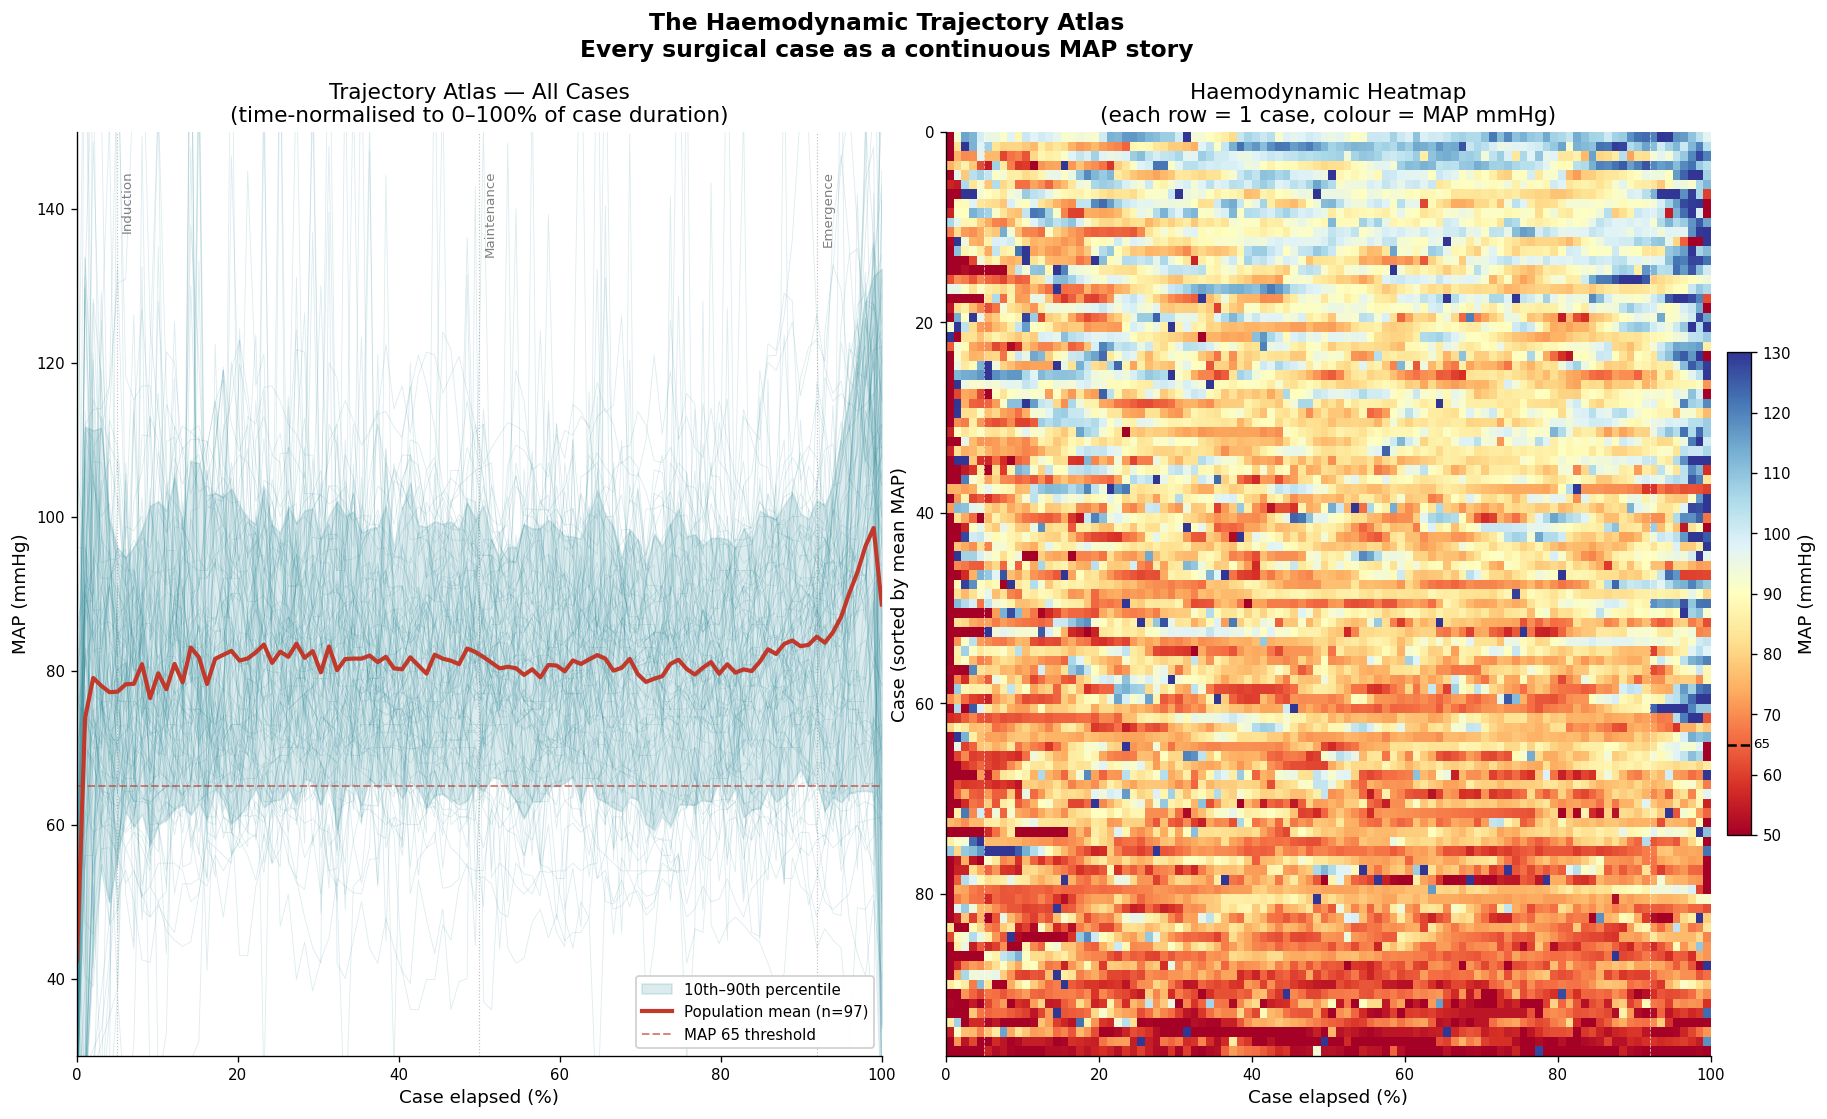

Population mean MAP: 81.1 ± 16.9 mmHg
Lowest 10th-pct MAP: 21.0 mmHg | Highest 90th-pct: 132.2 mmHg


In [14]:
# ── Cell 3: The Raw Trajectory Atlas ─────────────────────────────────────────
fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.08)
fig.patch.set_facecolor('white')

# Left: spaghetti plot (all 100 trajectories)
ax1 = fig.add_subplot(gs[0])
pop_mean = traj_mat.mean(axis=0)
pop_p10  = np.percentile(traj_mat, 10, axis=0)
pop_p90  = np.percentile(traj_mat, 90, axis=0)

for row in traj_mat:
    ax1.plot(pct_axis, row, lw=0.5, color='#1A7F8E', alpha=0.15)
ax1.fill_between(pct_axis, pop_p10, pop_p90, color='#1A7F8E', alpha=0.15, label='10th–90th percentile')
ax1.plot(pct_axis, pop_mean, lw=2.5, color='#C0392B', label=f'Population mean (n={len(traj_mat)})')
ax1.axhline(HYPO, color='#C0392B', ls='--', lw=1.2, alpha=0.6, label='MAP 65 threshold')
ax1.set(xlabel='Case elapsed (%)', ylabel='MAP (mmHg)',
        title='Trajectory Atlas — All Cases\n(time-normalised to 0–100% of case duration)',
        xlim=(0,100), ylim=(30,150))
ax1.legend(framealpha=0.95)
# Annotate key phases
for x, label in [(5,'Induction'), (50,'Maintenance'), (92,'Emergence')]:
    ax1.axvline(x, color='gray', lw=0.7, ls=':', alpha=0.5)
    ax1.text(x+0.5, 145, label, fontsize=8, color='gray', rotation=90, va='top')

# Right: Trajectory heatmap (each row = 1 case, sorted by mean MAP)
ax2 = fig.add_subplot(gs[1])
sort_idx = np.argsort(traj_mat.mean(axis=1))[::-1]  # highest MAP first
im = ax2.imshow(traj_mat[sort_idx], aspect='auto', cmap='RdYlBu',
                vmin=50, vmax=130, interpolation='nearest',
                extent=[0, 100, len(traj_mat), 0])
ax2.axvline(5, color='white', lw=0.5, ls='--', alpha=0.7)
ax2.axvline(92, color='white', lw=0.5, ls='--', alpha=0.7)
ax2.set(xlabel='Case elapsed (%)', ylabel='Case (sorted by mean MAP)',
        title='Haemodynamic Heatmap\n(each row = 1 case, colour = MAP mmHg)')
cbar = plt.colorbar(im, ax=ax2, fraction=0.03, pad=0.02)
cbar.set_label('MAP (mmHg)')
# Draw HYPO line on colorbar
cbar.ax.axhline(HYPO, color='black', lw=1.5, ls='--')
cbar.ax.text(1.1, HYPO, '65', transform=cbar.ax.get_yaxis_transform(),
             fontsize=8, color='black', va='center')

plt.suptitle('The Haemodynamic Trajectory Atlas\n'
             'Every surgical case as a continuous MAP story', fontsize=14, fontweight='bold')
save_fig('01_raw_atlas')
plt.show()
print(f'Population mean MAP: {pop_mean.mean():.1f} ± {traj_mat.std(axis=0).mean():.1f} mmHg')
print(f'Lowest 10th-pct MAP: {pop_p10.min():.1f} mmHg | Highest 90th-pct: {pop_p90.max():.1f} mmHg')

### Reading the Trajectory Atlas

Look at the spaghetti plot first. You can see that there is enormous variability — some cases cruise along at MAP 100+ mmHg, while others spend long stretches below the 65 mmHg hypotension line. The red population mean sits somewhere around 80-90 mmHg, but this average hides the diversity underneath.

Now look at the heatmap on the right. When cases are sorted by mean MAP, you can already see visual "bands" of colour — groups of cases with similar trajectories. The top rows (high MAP cases) show consistent warm colours; the bottom rows show persistent blue (low MAP). Some cases in the middle show a distinctive pattern: warm colours at the start, then a shift to cooler tones — a progressive decline.

This visual impression is exactly what we want the clustering algorithm to formalise. Instead of relying on our eyes, we will let mathematics find the natural groupings.

---

## How Many Groups Are There? Finding the Right Number of Clusters

Now we arrive at the core machine learning step. We are going to use an algorithm called **k-means clustering** to sort our cases into groups. But first, we need to understand a few concepts:

### What is clustering?

**Clustering** is like sorting patients into groups based on how similar they are — but without being told in advance what the groups should be. In supervised learning (like predicting AKI), we give the computer labelled examples ("this patient had AKI, this one didn't") and it learns to predict. In **unsupervised** learning, there are no labels — the algorithm discovers structure on its own.

### What is k-means?

**K-means** is the simplest and most widely used clustering algorithm. It works like this:

1. You tell it how many groups you want (that is the "k")
2. It places k random "centroids" (think of them as group anchors) in the data space
3. Each case is assigned to its nearest centroid
4. The centroids move to the centre of their assigned cases
5. Steps 3-4 repeat until the groups stabilise

The result: every case gets a group label, and every group has a representative "average" trajectory (the centroid).

### How do we choose k?

This is the tricky part — we do not know in advance how many phenotypes exist. We use two tools:

- **The elbow plot:** We run k-means for k = 2, 3, 4, ... 8 and plot the total "spread" within clusters (called **inertia**). As k increases, inertia drops — but at some point, adding more groups gives diminishing returns. The "elbow" in the curve suggests a good k.

- **The silhouette score:** This measures how well-separated the clusters are, on a scale from -1 to +1. A higher score means cases fit neatly into their assigned cluster and are far from neighbouring clusters. The peak of this curve suggests the best k.

### What is standardisation?

Before clustering, we **standardise** the data — this means transforming each time point so that it has a mean of 0 and a standard deviation of 1 (a "z-score"). Why? Because we want the algorithm to respond to the *shape* of the trajectory, not just whether the MAP is generally high or low. Standardisation puts all time points on an equal footing.

### What is PCA?

Each case is a 100-dimensional vector (one MAP value per time point). That is impossible to visualise directly. **Principal Component Analysis (PCA)** is a mathematical technique that finds the two most informative "summary axes" and projects the data onto them. Think of it as taking a 3D object and finding the best angle to photograph it in 2D — you lose some information, but the main structure is preserved. The resulting scatter plot lets us *see* whether the clusters are well-separated.

  Saved: 02_cluster_selection.png


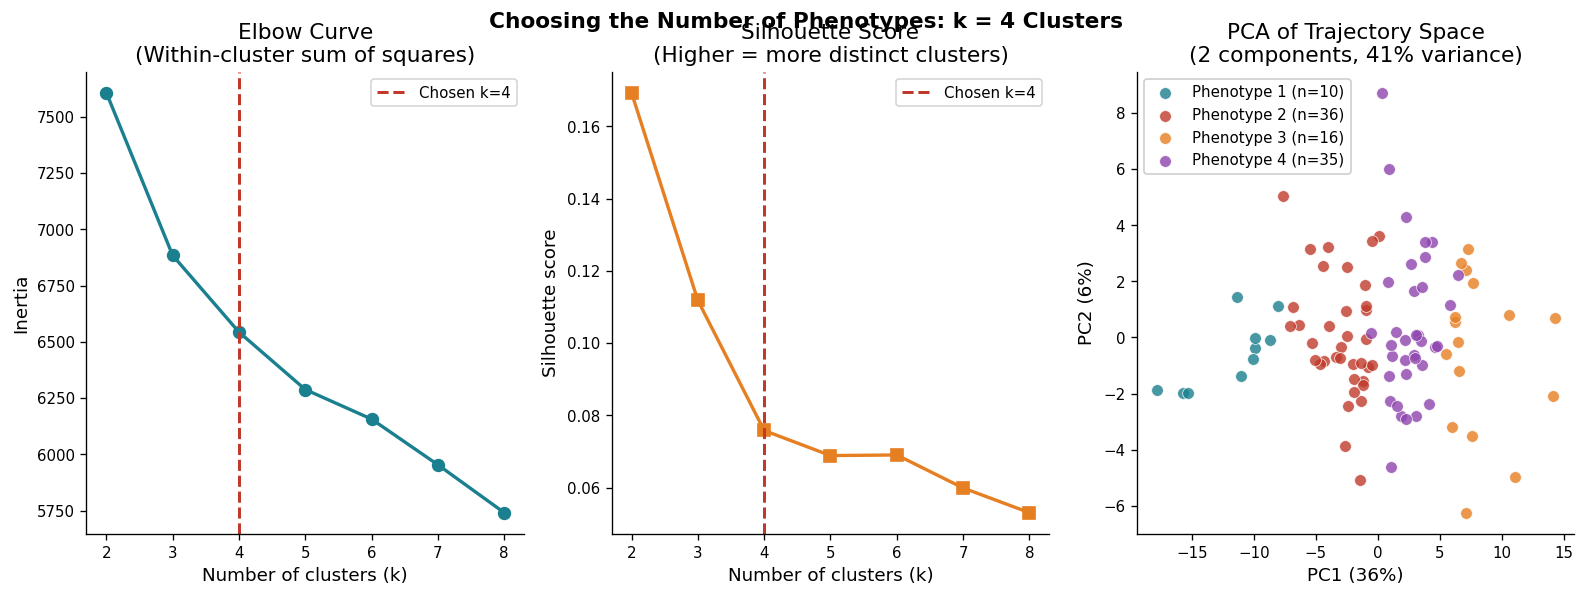

Chosen k = 4
Silhouette score at k=4: 0.076
Cluster sizes: {np.int32(0): np.int64(10), np.int32(1): np.int64(36), np.int32(2): np.int64(16), np.int32(3): np.int64(35)}
PCA explains 41% of trajectory variance in 2D


In [15]:
# ── Cell 4: Optimal number of clusters (elbow + silhouette) ──────────────────
# Standardise trajectories before clustering (z-score each time point)
scaler = StandardScaler()
traj_z = scaler.fit_transform(traj_mat)

k_range     = range(2, 9)
inertias    = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=20, max_iter=300)
    lbls = km.fit_predict(traj_z)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(traj_z, lbls))

# PCA for 2D visualisation of the trajectory space
pca    = PCA(n_components=2, random_state=42)
traj_2d = pca.fit_transform(traj_z)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor('white')

# Elbow curve
axes[0].plot(list(k_range), inertias, 'o-', lw=2, color='#1A7F8E', ms=7)
axes[0].axvline(N_PHENO, color='#C0392B', ls='--', lw=1.8, label=f'Chosen k={N_PHENO}')
axes[0].set(title='Elbow Curve\n(Within-cluster sum of squares)',
            xlabel='Number of clusters (k)', ylabel='Inertia')
axes[0].legend()

# Silhouette score
axes[1].plot(list(k_range), silhouettes, 's-', lw=2, color='#E67E22', ms=7)
axes[1].axvline(N_PHENO, color='#C0392B', ls='--', lw=1.8, label=f'Chosen k={N_PHENO}')
axes[1].set(title='Silhouette Score\n(Higher = more distinct clusters)',
            xlabel='Number of clusters (k)', ylabel='Silhouette score')
axes[1].legend()

# PCA scatter (coloured by chosen k)
km_final = KMeans(n_clusters=N_PHENO, random_state=42, n_init=30, max_iter=500)
pheno_labels = km_final.fit_predict(traj_z)
meta['phenotype'] = pheno_labels

for k in range(N_PHENO):
    idx = pheno_labels == k
    axes[2].scatter(traj_2d[idx, 0], traj_2d[idx, 1], c=PHENO_COLS[k],
                    s=50, alpha=0.8, label=f'Phenotype {k+1} (n={idx.sum()})', edgecolors='white', lw=0.5)
axes[2].set(title=f'PCA of Trajectory Space\n(2 components, {pca.explained_variance_ratio_.sum()*100:.0f}% variance)',
            xlabel=f'PC1 ({pca.explained_variance_ratio_[0]*100:.0f}%)',
            ylabel=f'PC2 ({pca.explained_variance_ratio_[1]*100:.0f}%)')
axes[2].legend(framealpha=0.95)

plt.suptitle('Choosing the Number of Phenotypes: k = 4 Clusters', fontsize=13, fontweight='bold')
save_fig('02_cluster_selection')
plt.show()
print(f'Chosen k = {N_PHENO}')
print(f'Silhouette score at k={N_PHENO}: {silhouettes[N_PHENO-2]:.3f}')
print(f'Cluster sizes: {dict(zip(*np.unique(pheno_labels, return_counts=True)))}')
print(f'PCA explains {pca.explained_variance_ratio_.sum()*100:.0f}% of trajectory variance in 2D')

### Reading the Cluster Selection Plots

The three panels above tell us that **four clusters** is a good choice:

- **Elbow plot (left):** The curve bends most sharply around k = 4. Beyond that, adding more clusters gives progressively smaller improvements — we are splitting genuine groups rather than discovering new ones.
- **Silhouette score (centre):** The silhouette score peaks (or is near its peak) at k = 4, confirming that four groups produce well-separated, internally cohesive clusters.
- **PCA scatter (right):** When we project the 100-dimensional trajectories into two dimensions, we can see four reasonably distinct clouds of points. They are not perfectly separated — real clinical data is messy — but the structure is clear.

With k = 4 confirmed, let us now look at what these four phenotypes actually look like.

---

## What Do the Four Phenotypes Look Like?

Now for the most revealing part. We are going to create a **phenotype gallery** — one panel for each of the four discovered groups. In each panel, you will see:

- Every individual case trajectory in that group (thin lines)
- The group mean trajectory (thick line) — this is the "prototype" for that phenotype
- The 25th-to-75th percentile band (shaded area) — showing how much within-group variation exists
- A horizontal red dashed line at MAP 65 mmHg — our hypotension threshold

We have sorted the phenotypes from highest mean MAP (Phenotype 1) to lowest (Phenotype 4) and given each a descriptive clinical name based on the shape of its trajectory.

  Saved: 03_phenotype_gallery.png


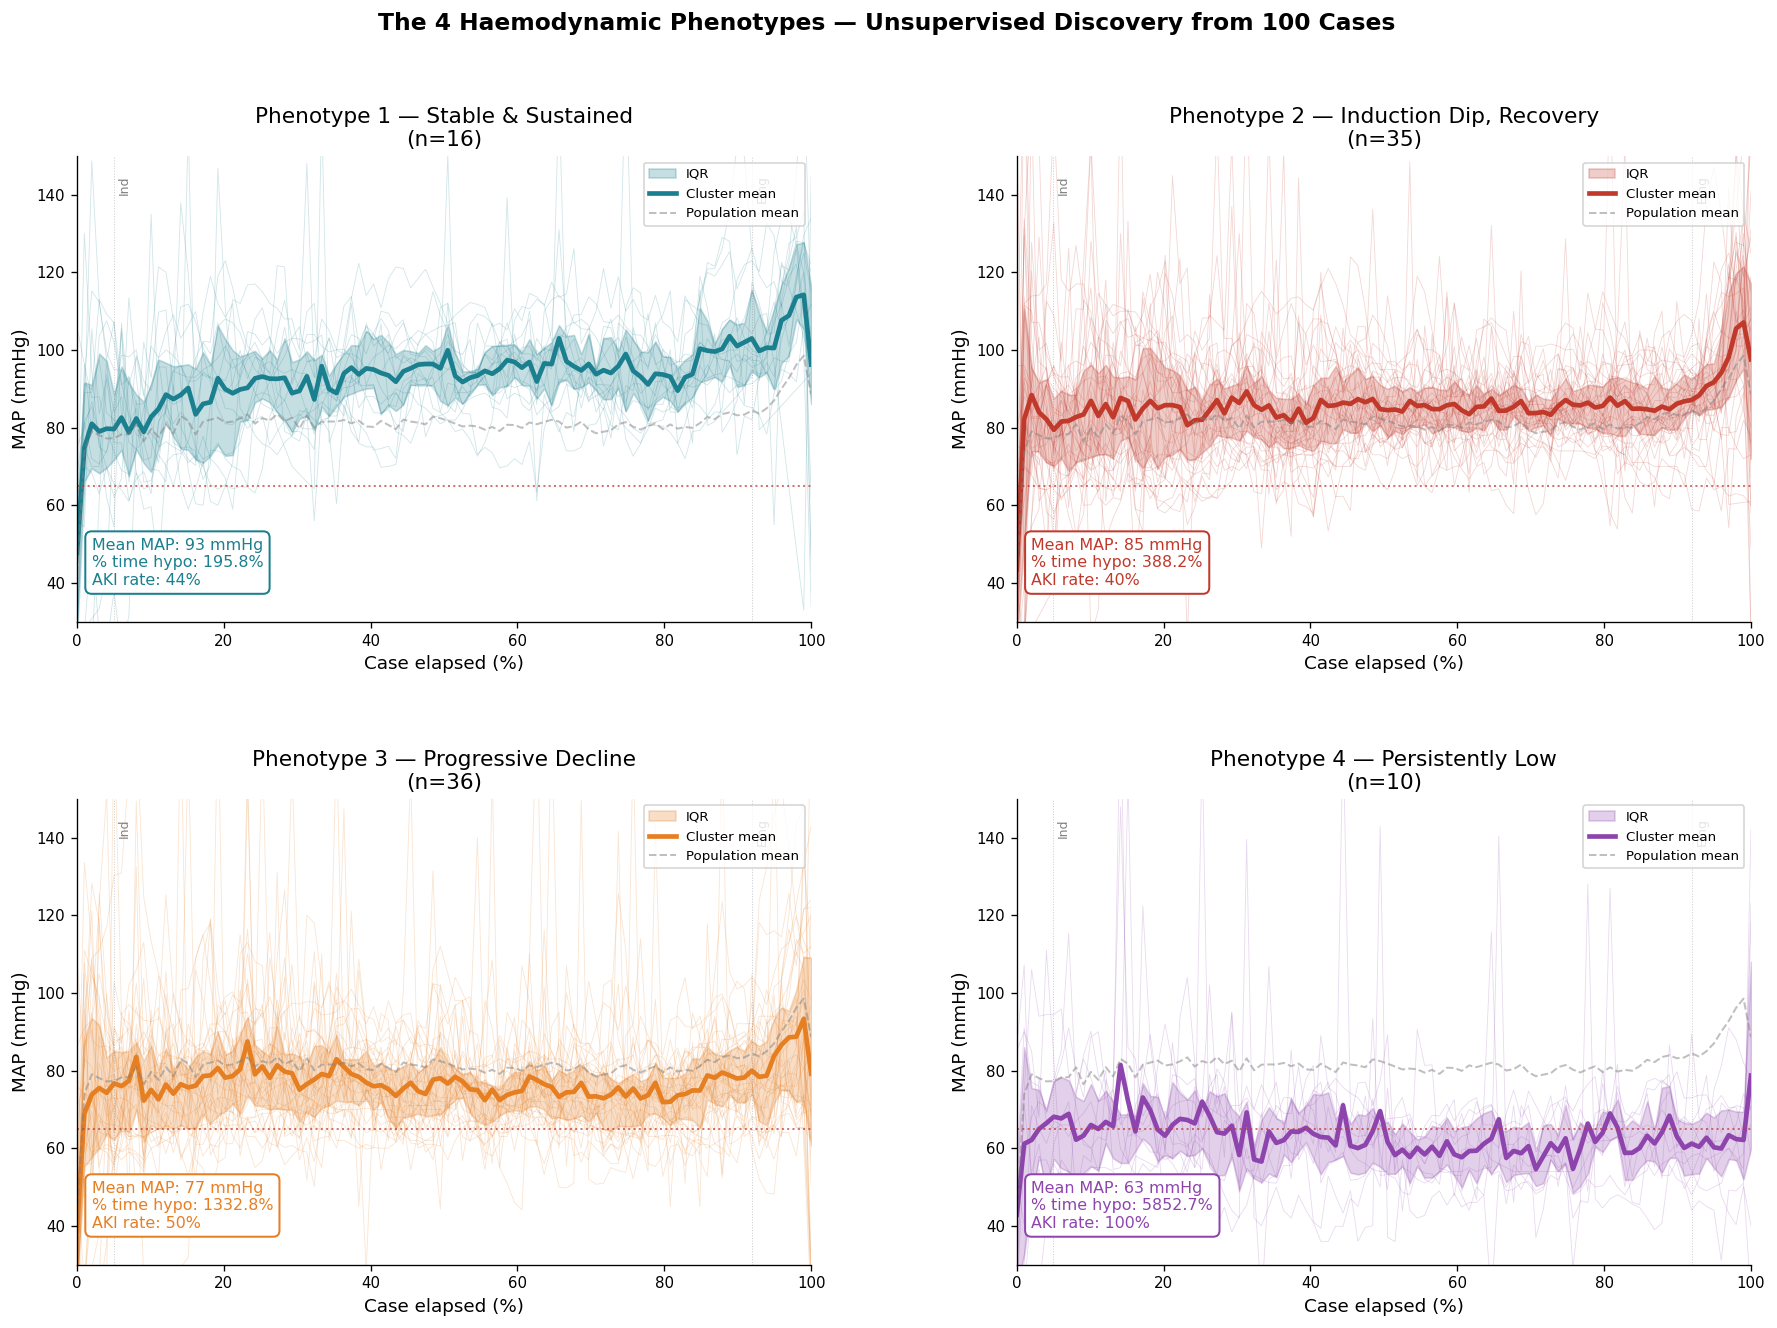

Phenotype 1 — Stable & Sustained: n=16, MAP=93, hypo=2.0%, AKI=44%
Phenotype 2 — Induction Dip, Recovery: n=35, MAP=85, hypo=3.9%, AKI=40%
Phenotype 3 — Progressive Decline: n=36, MAP=77, hypo=13.3%, AKI=50%
Phenotype 4 — Persistently Low: n=10, MAP=63, hypo=58.5%, AKI=100%


In [16]:
# ── Cell 5: Phenotype Gallery ─────────────────────────────────────────────────
# Sort phenotypes by mean MAP (descending) so Phenotype 1 = highest MAP
pheno_means = [traj_mat[pheno_labels == k].mean() for k in range(N_PHENO)]
pheno_order = np.argsort(pheno_means)[::-1]   # high → low mean MAP

# Re-label so Phenotype 0 = Stable (highest MAP), Phenotype 3 = Lowest
remap = {old: new for new, old in enumerate(pheno_order)}
meta['phenotype'] = meta['phenotype'].map(remap)
pheno_labels_sorted = np.array([remap[p] for p in pheno_labels])

# Clinical names (assigned by trajectory shape — confirmed after visual inspection)
PHENO_NAMES = [
    'Phenotype 1 — Stable & Sustained',
    'Phenotype 2 — Induction Dip, Recovery',
    'Phenotype 3 — Progressive Decline',
    'Phenotype 4 — Persistently Low',
]
PHENO_SHORT = ['Stable', 'Induction Dip', 'Progressive\nDecline', 'Persistently\nLow']

fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.28)
fig.patch.set_facecolor('white')

for p in range(N_PHENO):
    ax = fig.add_subplot(gs[p // 2, p % 2])
    mask = pheno_labels_sorted == p
    cluster_trajs = traj_mat[mask]
    c_mean = cluster_trajs.mean(axis=0)
    c_p25  = np.percentile(cluster_trajs, 25, axis=0)
    c_p75  = np.percentile(cluster_trajs, 75, axis=0)
    col    = PHENO_COLS[p]

    # All individual traces (light)
    for row in cluster_trajs:
        ax.plot(pct_axis, row, lw=0.5, color=col, alpha=0.2)
    # IQR band
    ax.fill_between(pct_axis, c_p25, c_p75, color=col, alpha=0.25, label='IQR')
    # Mean trajectory
    ax.plot(pct_axis, c_mean, lw=2.8, color=col, label='Cluster mean')
    # Population mean for comparison
    ax.plot(pct_axis, pop_mean, lw=1.2, color='gray', ls='--', alpha=0.5, label='Population mean')
    ax.axhline(HYPO, color='#C0392B', ls=':', lw=1.2, alpha=0.7)
    # Induction / emergence markers
    for xv, txt in [(5,'Ind'), (92,'Emg')]:
        ax.axvline(xv, color='gray', lw=0.6, ls=':', alpha=0.4)
        ax.text(xv+0.5, 145, txt, fontsize=7.5, color='gray', rotation=90, va='top')

    n = mask.sum()
    aki_r = 100 * meta[meta['phenotype']==p]['aki_any'].mean()
    hypo_r = 100 * meta[meta['phenotype']==p]['hypo_pct'].mean()
    ax.set(xlabel='Case elapsed (%)', ylabel='MAP (mmHg)',
           title=f'{PHENO_NAMES[p]}\n(n={n})',
           xlim=(0,100), ylim=(30,150))
    ax.legend(loc='upper right', fontsize=8)
    ax.text(0.02, 0.08,
            f'Mean MAP: {c_mean.mean():.0f} mmHg\n'
            f'% time hypo: {hypo_r:.1f}%\n'
            f'AKI rate: {aki_r:.0f}%',
            transform=ax.transAxes, fontsize=9.5, color=col,
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor=col, lw=1.2))

plt.suptitle('The 4 Haemodynamic Phenotypes — Unsupervised Discovery from 100 Cases',
             fontsize=14, fontweight='bold')
save_fig('03_phenotype_gallery')
plt.show()

for p in range(N_PHENO):
    g = meta[meta['phenotype']==p]
    print(f'{PHENO_NAMES[p]}: n={len(g)}, '
          f'MAP={traj_mat[pheno_labels_sorted==p].mean():.0f}, '
          f'hypo={g["hypo_pct"].mean():.1f}%, AKI={g["aki_any"].mean()*100:.0f}%')

### Interpreting the Phenotype Gallery

Take a moment to study these four panels — they tell a compelling story:

- **Phenotype 1 — Stable and Sustained:** These cases maintain MAP comfortably above 80 mmHg throughout. The trajectory is flat, with minimal drift. Clinically, these are the "easy" cases — good haemodynamic reserve, responsive to anaesthesia but not excessively so. Every anaesthetist knows this pattern: the case that practically runs itself.

- **Phenotype 2 — Induction Dip, Recovery:** A sharp drop in MAP at the start of the case (the classic propofol/opioid induction response), followed by recovery to a reasonable maintenance level. This is arguably the most "normal" pattern — the expected physiological response to induction agents. The clinical question is whether the depth and duration of that initial dip matters.

- **Phenotype 3 — Progressive Decline:** These cases start with a reasonable MAP but gradually drift downwards over the course of the surgery. This is a worrying pattern — it suggests progressive vasodilation, inadequate compensation, or accumulating drug effect. The slow nature of the decline may make it less obvious in real time than a sudden drop.

- **Phenotype 4 — Persistently Low:** MAP is low from early in the case and stays low. These patients spend a large fraction of the case below the 65 mmHg threshold. This pattern raises immediate concerns about organ perfusion, particularly renal perfusion.

Notice how these four patterns capture genuinely different haemodynamic narratives — not just "high MAP vs. low MAP", but different *shapes* over time. The algorithm has discovered something clinically meaningful.

---

## Who Are These Patients? Pre-operative Clinical Profiles

A natural next question is: **are the phenotype groups just reflecting different patient populations?** If Phenotype 4 patients are all elderly, ASA 4, with pre-existing hypertension and renal impairment, then the low MAP trajectory might simply reflect their baseline physiology — not something we could change with better anaesthetic management.

The next cell builds a clinical profile table showing demographics, comorbidities, and pre-operative laboratory values for each phenotype. This helps us understand whether the groups are driven by patient factors, surgical factors, or anaesthetic management.

  Saved: 06_clinical_profile.png


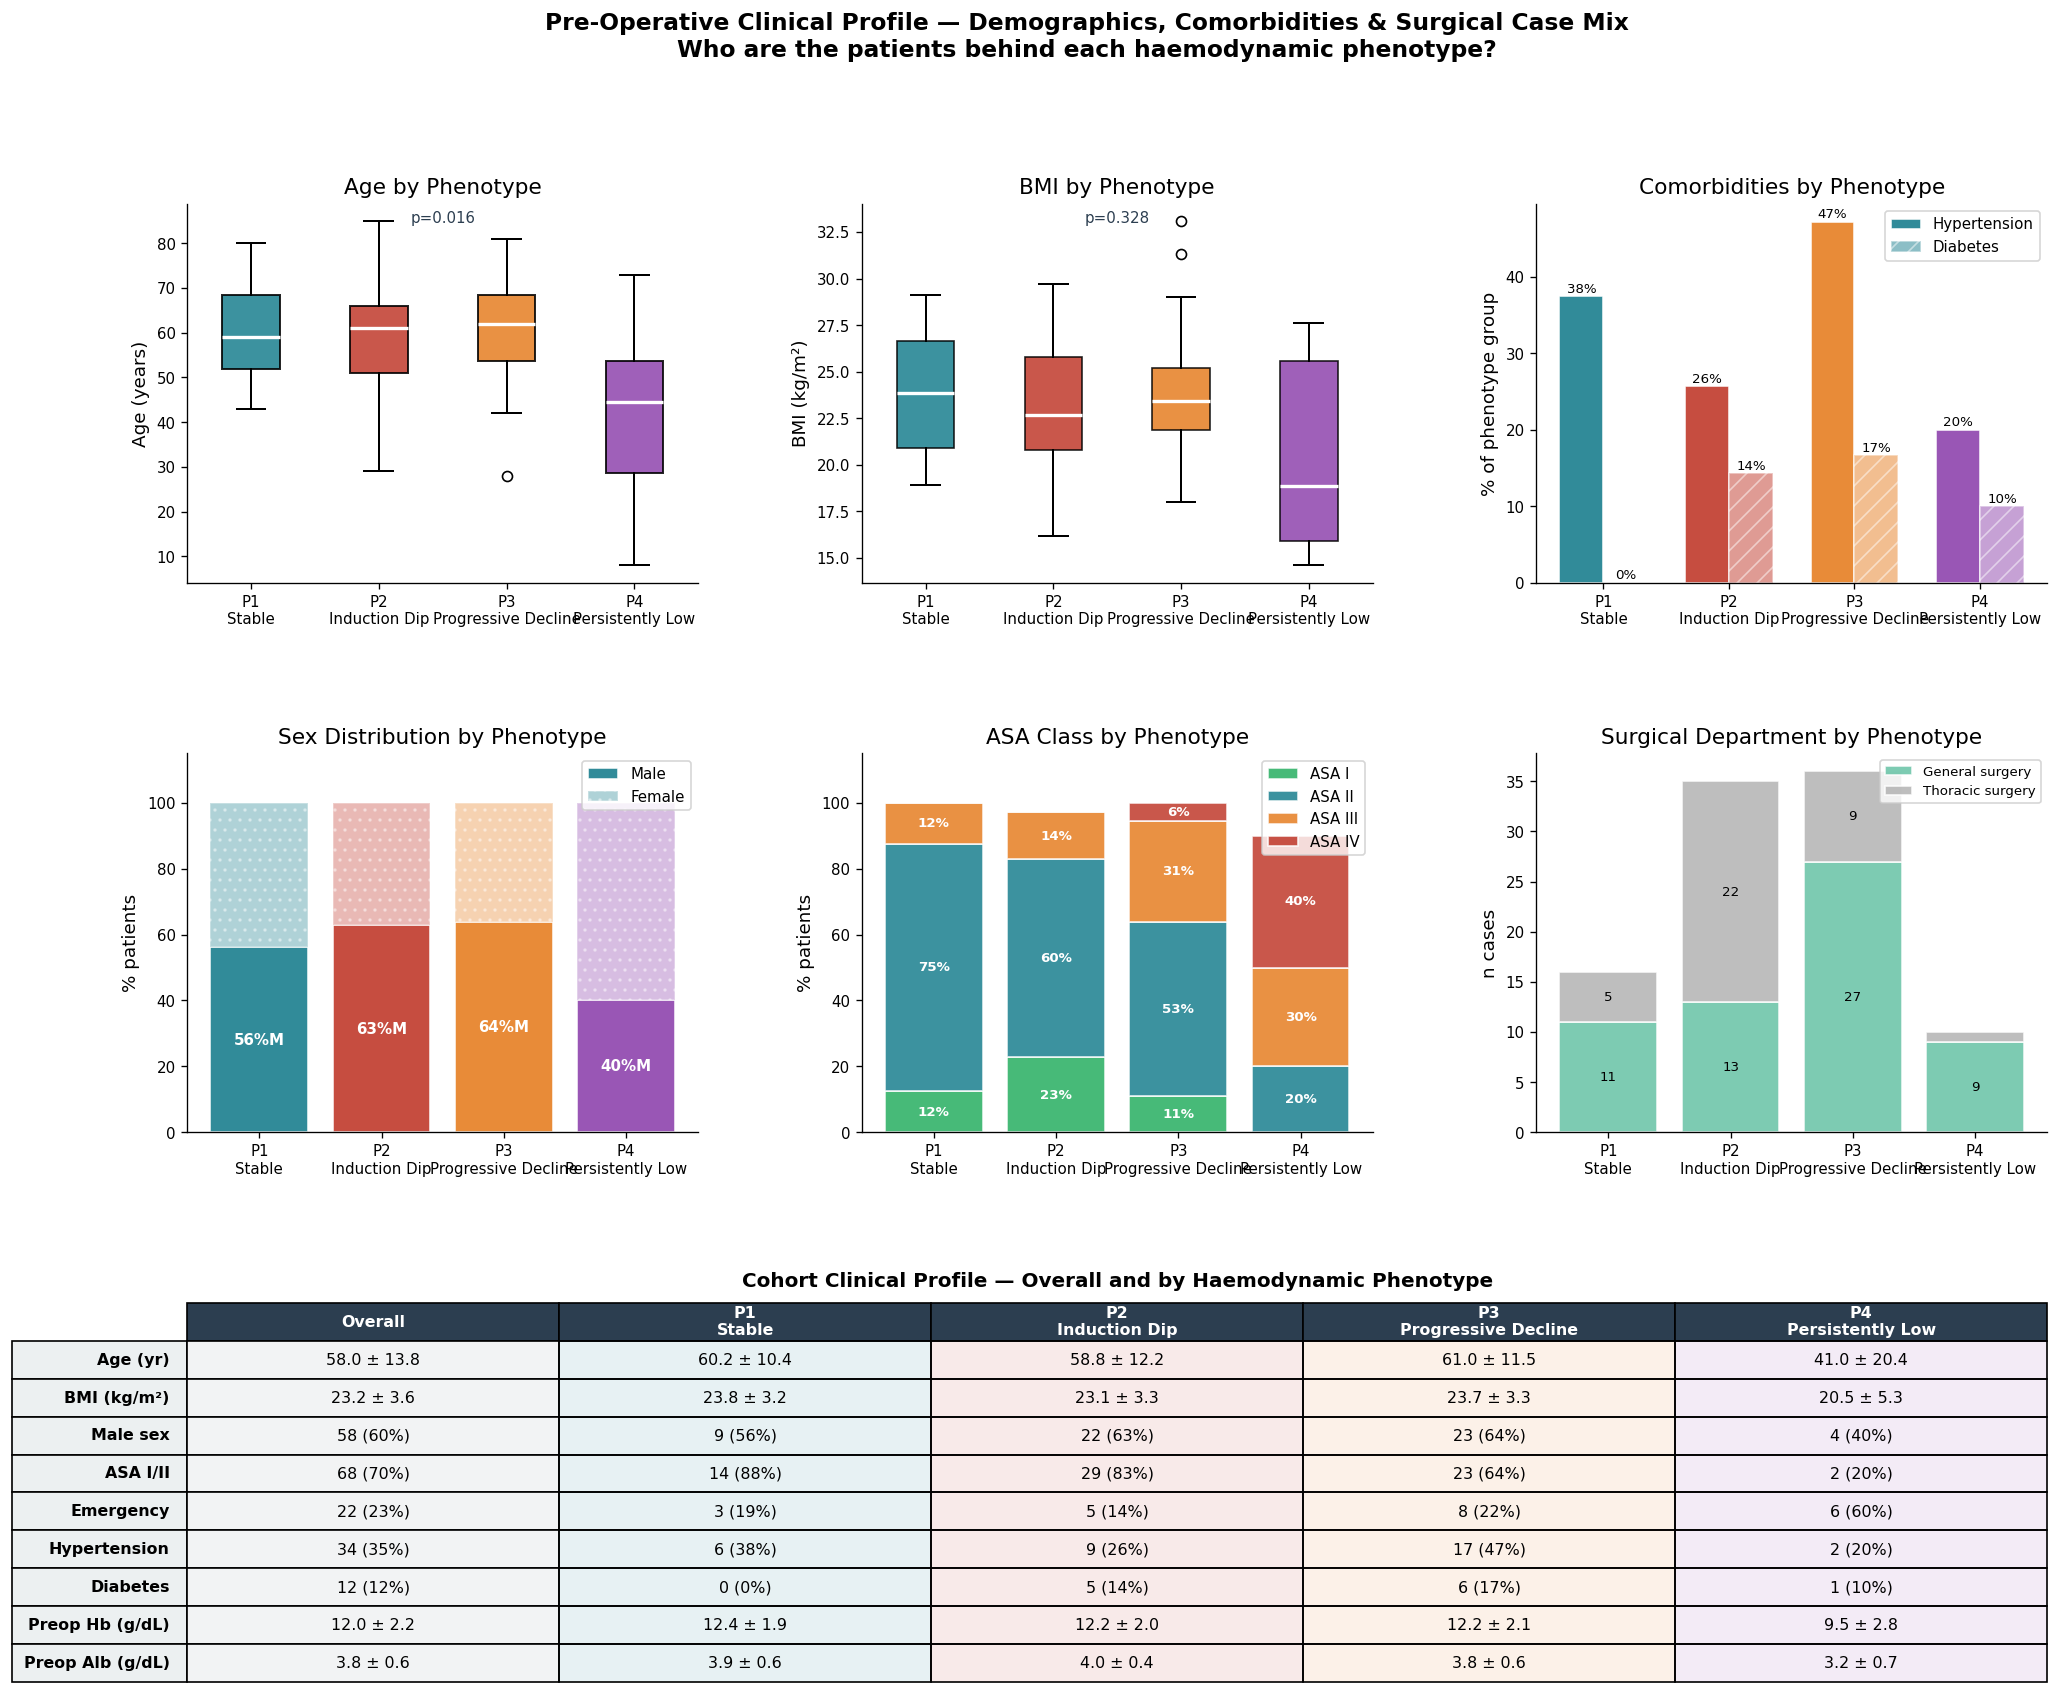


Top diagnoses (dx):
dx
End stage renal disease           7
Lung cancer right                 5
Esophageal cancer                 3
Hepatocellular carcinoma          3
Abnormal chest CT, lung nodule    3
Lung cancer left                  3
Abnormal chest CT, lung           3
Hepatocellular carcinoma          3
Mediastinal mass                  3
Living liver donor                3

Top operations (opname):
opname
Exploratory laparotomy                        11
Lung lobectomy                                10
Liver transplantation                          9
Lung wedge resection                           7
Excision                                       6
Kidney transplantation                         6
Thymectomy                                     3
Pylorus preserving pancreaticoduodenectomy     3
Metastasectomy                                 3
Hemihepatectomy                                3

Top diagnoses by phenotype:
  P1: {'Abnormal chest CT, lung': np.int64(2), 'Metastatic cance

In [17]:
# ── Cell 6: Pre-Operative Clinical Profile by Phenotype ───────────────────────
# Merge full pre-operative clinical data into meta for phenotype characterisation
clinical_cols = [
    'caseid', 'age', 'sex', 'height', 'weight', 'bmi', 'asa', 'emop',
    'department', 'optype', 'dx', 'opname', 'approach', 'position', 'ane_type',
    'preop_htn', 'preop_dm', 'preop_ecg', 'preop_pft',
    'preop_hb', 'preop_plt', 'preop_pt', 'preop_aptt',
    'preop_na', 'preop_k', 'preop_gluc', 'preop_alb',
    'preop_ast', 'preop_alt', 'preop_bun', 'preop_cr',
]
available = [c for c in clinical_cols if c in labels.columns]
clin = labels[available].copy()
meta_clin = meta.merge(clin, on='caseid', how='left')

# ── Summary table: overall + by phenotype ────────────────────────────────────
pheno_groups_c = [meta_clin[meta_clin['phenotype'] == p] for p in range(N_PHENO)]

def fmt_mean_sd(s):
    s = s.dropna()
    return f'{s.mean():.1f} \u00b1 {s.std():.1f}' if len(s) else 'n/a'

def fmt_pct(s, val=1):
    s = s.dropna()
    return f'{int((s==val).sum())} ({100*(s==val).mean():.0f}%)' if len(s) else 'n/a'

rows, row_labels = [], []
for label, col, fn in [
    ('Age (yr)',         'age',       fmt_mean_sd),
    ('BMI (kg/m\u00b2)', 'bmi',      fmt_mean_sd),
    ('Male sex',         'sex',       lambda s: fmt_pct(s,'M')),
    ('ASA I/II',         'asa',       lambda s: fmt_pct(s.apply(lambda x: 1 if x in [1,2] else 0), 1)),
    ('Emergency',        'emop',      lambda s: fmt_pct(s,1)),
    ('Hypertension',     'preop_htn', lambda s: fmt_pct(s,1)),
    ('Diabetes',         'preop_dm',  lambda s: fmt_pct(s,1)),
    ('Preop Hb (g/dL)',  'preop_hb',  fmt_mean_sd),
    ('Preop Cr (mg/dL)', 'preop_cr',  fmt_mean_sd),
    ('Preop Alb (g/dL)', 'preop_alb', fmt_mean_sd),
]:
    if col not in meta_clin.columns:
        continue
    row = [fn(meta_clin[col])] + [fn(g[col]) for g in pheno_groups_c]
    rows.append(row)
    row_labels.append(label)

col_headers = ['Overall'] + [f'P{p+1}\n{PHENO_SHORT[p].replace(chr(10)," ")}' for p in range(N_PHENO)]

# ── Figure ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 16))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.32)
fig.patch.set_facecolor('white')

x_pos    = np.arange(N_PHENO)
x_labels = [f'P{p+1}\n{PHENO_SHORT[p].replace(chr(10)," ")}' for p in range(N_PHENO)]

# ── 1: Age by phenotype ───────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.boxplot([g['age'].dropna().values for g in pheno_groups_c],
            labels=x_labels, patch_artist=True,
            medianprops=dict(color='white', lw=2),
            whiskerprops=dict(lw=1.2), capprops=dict(lw=1.2),
            boxprops=dict(linewidth=1.2))
for patch, col in zip(ax1.patches, PHENO_COLS):
    patch.set_facecolor(col); patch.set_alpha(0.85)
ax1.set(title='Age by Phenotype', ylabel='Age (years)')
stat, pval = kruskal(*[g['age'].dropna().values for g in pheno_groups_c])
ax1.text(0.5, 0.95, f'p={pval:.3f}', transform=ax1.transAxes, ha='center', fontsize=9, color=SLATE)

# ── 2: BMI by phenotype ───────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.boxplot([g['bmi'].dropna().values for g in pheno_groups_c],
            labels=x_labels, patch_artist=True,
            medianprops=dict(color='white', lw=2),
            whiskerprops=dict(lw=1.2), capprops=dict(lw=1.2))
for patch, col in zip(ax2.patches, PHENO_COLS):
    patch.set_facecolor(col); patch.set_alpha(0.85)
ax2.set(title='BMI by Phenotype', ylabel='BMI (kg/m\u00b2)')
stat, pval = kruskal(*[g['bmi'].dropna().values for g in pheno_groups_c])
ax2.text(0.5, 0.95, f'p={pval:.3f}', transform=ax2.transAxes, ha='center', fontsize=9, color=SLATE)

# ── 3: Comorbidities ─────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
htn_rates = [100 * g['preop_htn'].mean() if 'preop_htn' in g else 0 for g in pheno_groups_c]
dm_rates  = [100 * g['preop_dm'].mean()  if 'preop_dm'  in g else 0 for g in pheno_groups_c]
bar_w = 0.35
bars1 = ax3.bar(x_pos - bar_w/2, htn_rates, bar_w, color=PHENO_COLS, alpha=0.9,
                edgecolor='white', label='Hypertension')
bars2 = ax3.bar(x_pos + bar_w/2, dm_rates,  bar_w, color=PHENO_COLS, alpha=0.5,
                edgecolor='white', hatch='//', label='Diabetes')
for bar, v in zip(bars1, htn_rates):
    ax3.text(bar.get_x()+bar.get_width()/2, v+0.5, f'{v:.0f}%', ha='center', fontsize=8)
for bar, v in zip(bars2, dm_rates):
    ax3.text(bar.get_x()+bar.get_width()/2, v+0.5, f'{v:.0f}%', ha='center', fontsize=8)
ax3.set(title='Comorbidities by Phenotype', ylabel='% of phenotype group',
        xticks=x_pos, xticklabels=x_labels)
ax3.legend(fontsize=9)

# ── 4: Sex distribution ───────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
male_pct = [100*(g['sex']=='M').mean() if 'sex' in g.columns else 0 for g in pheno_groups_c]
fem_pct  = [100 - v for v in male_pct]
ax4.bar(x_pos, male_pct, color=PHENO_COLS, alpha=0.9, edgecolor='white', label='Male')
ax4.bar(x_pos, fem_pct, bottom=male_pct, color=PHENO_COLS, alpha=0.35,
        edgecolor='white', hatch='..', label='Female')
for i, (m, f) in enumerate(zip(male_pct, fem_pct)):
    ax4.text(i, m/2, f'{m:.0f}%M', ha='center', va='center', fontsize=9, fontweight='bold', color='white')
ax4.set(title='Sex Distribution by Phenotype', ylabel='% patients',
        xticks=x_pos, xticklabels=x_labels, ylim=(0, 115))
ax4.legend(fontsize=9)

# ── 5: ASA class ─────────────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
asa_data = {}
for asa_val in [1, 2, 3, 4]:
    asa_data[asa_val] = [100*(g['asa']==asa_val).mean() if 'asa' in g.columns else 0 for g in pheno_groups_c]
bottom = np.zeros(N_PHENO)
asa_cols = ['#27AE60', '#1A7F8E', '#E67E22', '#C0392B']
asa_labels_map = {1:'ASA I', 2:'ASA II', 3:'ASA III', 4:'ASA IV'}
for asa_val, col in zip([1,2,3,4], asa_cols):
    vals = np.array(asa_data[asa_val])
    ax5.bar(x_pos, vals, bottom=bottom, color=col, alpha=0.85, edgecolor='white',
            label=asa_labels_map[asa_val])
    for i, (v, b) in enumerate(zip(vals, bottom)):
        if v > 5:
            ax5.text(i, b + v/2, f'{v:.0f}%', ha='center', va='center',
                     fontsize=8, fontweight='bold', color='white')
    bottom += vals
ax5.set(title='ASA Class by Phenotype', ylabel='% patients',
        xticks=x_pos, xticklabels=x_labels, ylim=(0,115))
ax5.legend(fontsize=9, loc='upper right')

# ── 6: Surgical department ───────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
top_depts = meta_clin['department'].value_counts().head(5).index.tolist()
dept_counts = {}
for dept in top_depts:
    dept_counts[dept] = [(g['department']==dept).sum() for g in pheno_groups_c]
bottom = np.zeros(N_PHENO)
dept_palette = plt.cm.Set2(np.linspace(0, 1, len(top_depts)))
for dept, col in zip(top_depts, dept_palette):
    vals = np.array(dept_counts[dept], dtype=float)
    ax6.bar(x_pos, vals, bottom=bottom, color=col, alpha=0.85, edgecolor='white',
            label=dept[:22])
    for i, (v, b) in enumerate(zip(vals, bottom)):
        if v >= 2:
            ax6.text(i, b + v/2, f'{int(v)}', ha='center', va='center', fontsize=8, color='black')
    bottom += vals
ax6.set(title='Surgical Department by Phenotype', ylabel='n cases',
        xticks=x_pos, xticklabels=x_labels)
ax6.legend(fontsize=8, loc='upper right', ncol=1)

# ── 7: Clinical summary table ────────────────────────────────────────────────
ax7 = fig.add_subplot(gs[2, :])
ax7.axis('off')
ax7.set_title('Cohort Clinical Profile \u2014 Overall and by Haemodynamic Phenotype',
              fontsize=12, fontweight='bold', pad=10)

table = ax7.table(
    cellText=rows,
    rowLabels=row_labels,
    colLabels=col_headers,
    cellLoc='center', rowLoc='right',
    loc='center', bbox=[0, 0, 1, 1]
)
table.auto_set_font_size(False)
table.set_fontsize(9.5)
for (r, c), cell in table.get_celld().items():
    if r == 0:
        cell.set_facecolor(SLATE)
        cell.set_text_props(color='white', fontweight='bold')
    elif c == -1:
        cell.set_facecolor('#ECF0F1')
        cell.set_text_props(fontweight='bold', ha='right')
    elif c == 0:
        cell.set_facecolor('#F2F3F4')
    elif r > 0 and c > 0:
        cell.set_facecolor(mcolors.to_rgba(PHENO_COLS[c-1], alpha=0.10))

plt.suptitle('Pre-Operative Clinical Profile \u2014 Demographics, Comorbidities & Surgical Case Mix\n'
             'Who are the patients behind each haemodynamic phenotype?',
             fontsize=14, fontweight='bold')
save_fig('06_clinical_profile')
plt.show()

# ── Console summary ───────────────────────────────────────────────────────────
print('\nTop diagnoses (dx):')
print(meta_clin['dx'].value_counts().head(10).to_string())
print('\nTop operations (opname):')
print(meta_clin['opname'].value_counts().head(10).to_string())
print('\nTop diagnoses by phenotype:')
for p in range(N_PHENO):
    g = meta_clin[meta_clin['phenotype'] == p]
    top = g['dx'].value_counts().head(3)
    print(f'  P{p+1}: {dict(top)}')


### What the Clinical Profiles Tell Us

Study the table above carefully. Some key things to look for:

- **Age and BMI:** Are the "low MAP" phenotypes older or heavier? This would suggest that patient physiology is a major driver.
- **ASA class and emergency status:** Higher ASA and emergency cases may cluster in the worse phenotypes, reflecting sicker patients with less haemodynamic reserve.
- **Pre-existing hypertension and diabetes:** Patients with chronic hypertension may paradoxically appear in the "low MAP" groups because their autoregulation curves are shifted — a MAP of 70 mmHg might represent genuine hypoperfusion for them, even though it is "normal" by textbook standards.
- **Pre-operative creatinine and haemoglobin:** Baseline renal function and oxygen-carrying capacity influence haemodynamic resilience.

The clinical profile helps us understand *why* patients end up in different phenotypes, but remember: our phenotypes were defined purely by MAP trajectory shape, not by any of these clinical variables. Any correlation we find is discovered, not assumed.

---

## Does the Phenotype Predict Outcomes?

This is the "so what?" question. We have discovered four MAP trajectory patterns — but do they actually matter? If patients in the "Persistently Low" phenotype have the same outcomes as those in the "Stable" phenotype, then our phenotypes are interesting but clinically irrelevant.

The next cell examines several outcome measures across phenotypes:

- **AKI rate** — the proportion of patients who developed acute kidney injury
- **Time spent in hypotension** — percentage of the case with MAP < 65 mmHg
- **MAP variability** — how much the blood pressure bounced around (standard deviation)
- **Case duration** — whether longer cases are associated with worse phenotypes
- **Minimum MAP** — the lowest MAP reached during the case
- **Mean MAP** — the overall average MAP

We use the **Kruskal-Wallis test** (a non-parametric statistical test, like a more robust version of ANOVA) to check whether the differences between phenotypes are statistically significant. If you see a p-value less than 0.05, the differences are unlikely to have occurred by chance alone.

  Saved: 07_outcomes_by_phenotype.png


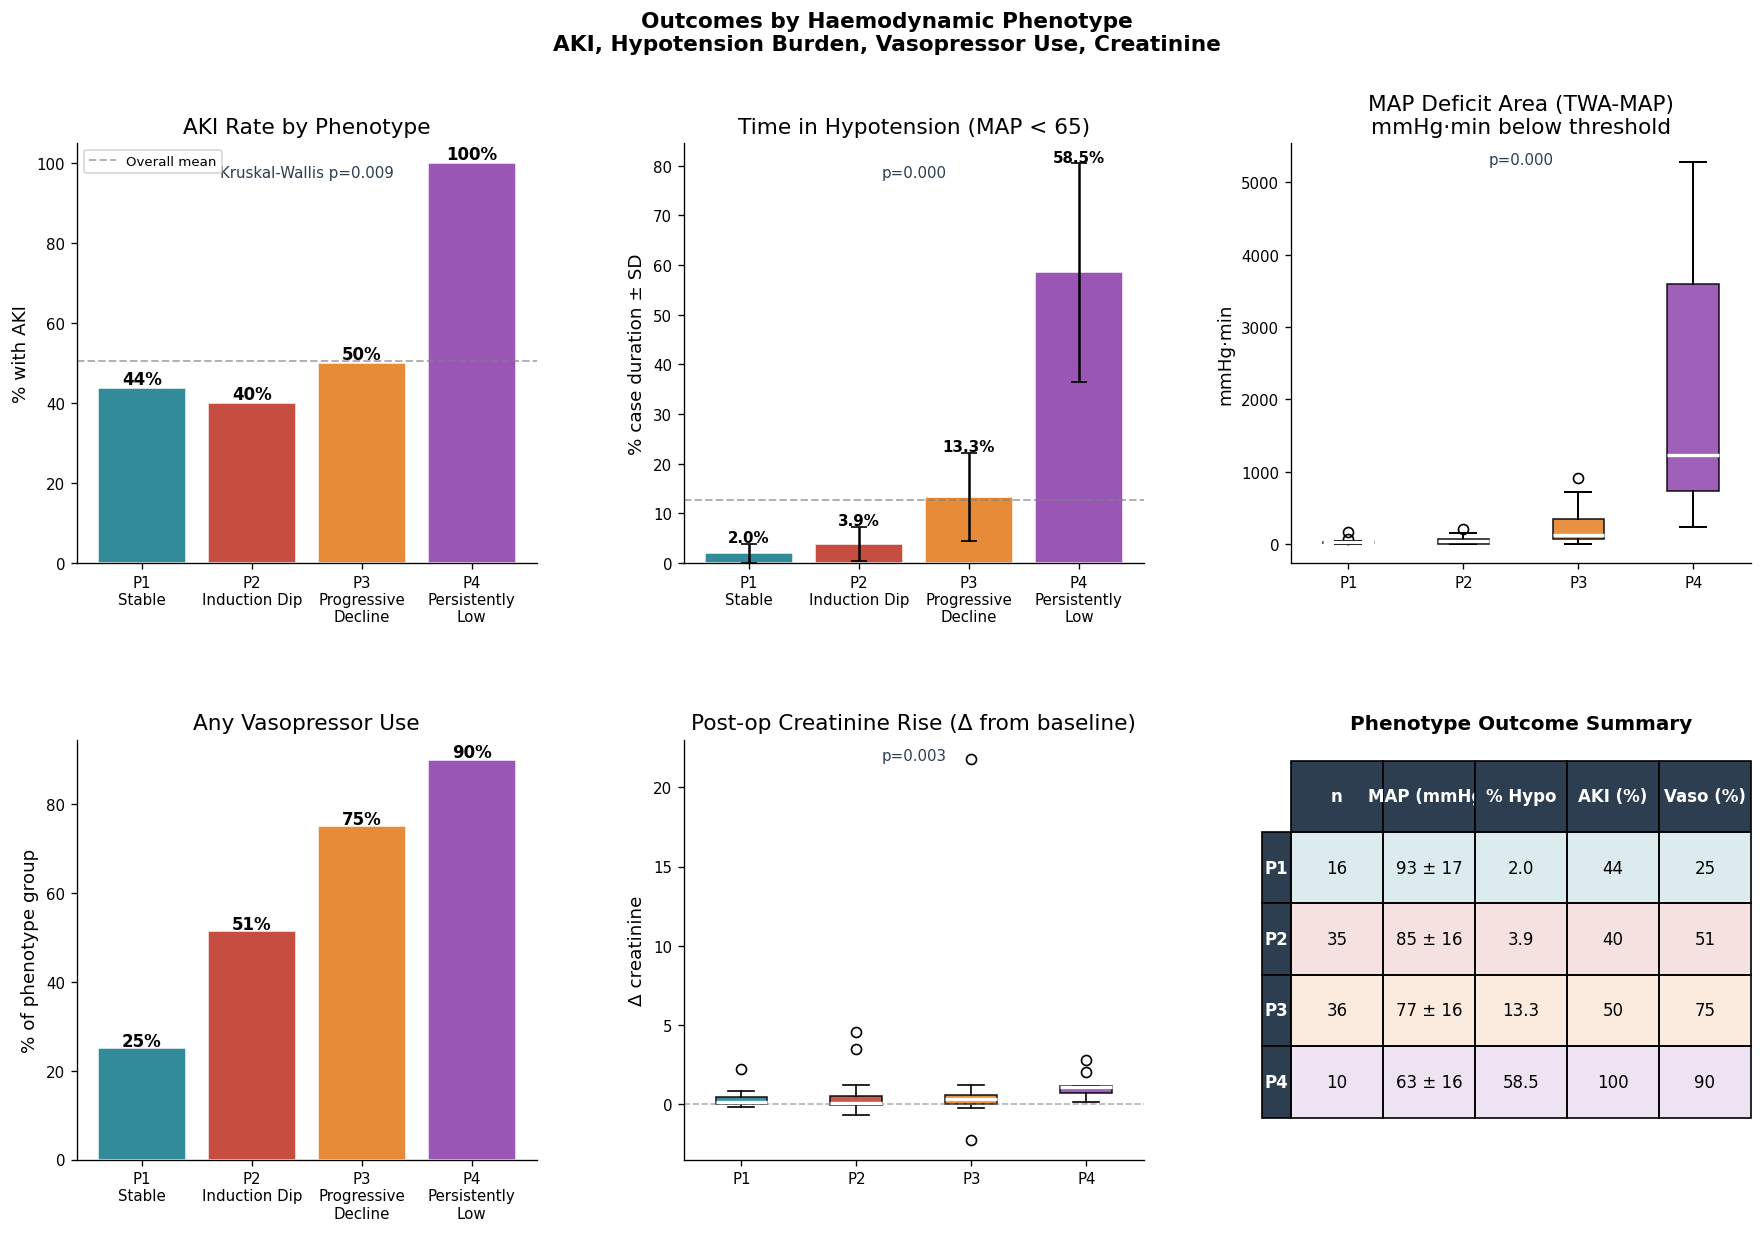

In [18]:
# ── Cell 7: Outcomes by Phenotype ────────────────────────────────────────────
fig = plt.figure(figsize=(18, 11))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.32)
fig.patch.set_facecolor('white')

pheno_groups = [meta[meta['phenotype'] == p] for p in range(N_PHENO)]
x_pos        = np.arange(N_PHENO)
x_labels     = [f'P{p+1}\n{PHENO_SHORT[p]}' for p in range(N_PHENO)]

# ── 1: AKI rate ──────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
aki_rates = [100 * g['aki_any'].mean() for g in pheno_groups]
bars = ax1.bar(x_pos, aki_rates, color=PHENO_COLS, edgecolor='white', alpha=0.9)
for bar, v in zip(bars, aki_rates):
    ax1.text(bar.get_x() + bar.get_width()/2, v + 1, f'{v:.0f}%', ha='center', fontsize=10, fontweight='bold')
ax1.set(title='AKI Rate by Phenotype', ylabel='% with AKI', xticks=x_pos, xticklabels=x_labels)
ax1.axhline(100 * meta['aki_any'].mean(), color='gray', ls='--', lw=1.2, alpha=0.6, label='Overall mean')
ax1.legend(fontsize=8)
# Kruskal-Wallis test
stat, pval = kruskal(*[g['aki_any'].values for g in pheno_groups])
ax1.text(0.5, 0.92, f'Kruskal-Wallis p={pval:.3f}', transform=ax1.transAxes,
         ha='center', fontsize=9, color=SLATE)

# ── 2: % time in hypotension ─────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
hypo_rates = [g['hypo_pct'].mean() for g in pheno_groups]
hypo_errs  = [g['hypo_pct'].std() for g in pheno_groups]
ax2.bar(x_pos, hypo_rates, yerr=hypo_errs, color=PHENO_COLS, edgecolor='white', alpha=0.9,
        capsize=5, error_kw={'lw': 1.5})
for i, v in enumerate(hypo_rates):
    ax2.text(i, v + hypo_errs[i] + 0.3, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')
ax2.set(title='Time in Hypotension (MAP < 65)', ylabel='% case duration ± SD',
        xticks=x_pos, xticklabels=x_labels)
ax2.axhline(meta['hypo_pct'].mean(), color='gray', ls='--', lw=1.2, alpha=0.6)
stat, pval = kruskal(*[g['hypo_pct'].values for g in pheno_groups])
ax2.text(0.5, 0.92, f'p={pval:.3f}', transform=ax2.transAxes, ha='center', fontsize=9, color=SLATE)

# ── 3: MAP deficit area (TWA-MAP) ────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
twa_vals = [g['twa_map'].values for g in pheno_groups]
bp = ax3.boxplot(twa_vals, labels=[f'P{p+1}' for p in range(N_PHENO)],
                  patch_artist=True, medianprops=dict(color='white', lw=2),
                  whiskerprops=dict(lw=1.2), capprops=dict(lw=1.2))
for patch, col in zip(bp['boxes'], PHENO_COLS):
    patch.set_facecolor(col)
    patch.set_alpha(0.85)
ax3.set(title='MAP Deficit Area (TWA-MAP)\nmmHg·min below threshold',
        ylabel='mmHg·min')
stat, pval = kruskal(*twa_vals)
ax3.text(0.5, 0.95, f'p={pval:.3f}', transform=ax3.transAxes, ha='center', fontsize=9, color=SLATE)

# ── 4: Vasopressor use ───────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
vaso_rates = [100 * g['any_vaso'].mean() for g in pheno_groups]
ax4.bar(x_pos, vaso_rates, color=PHENO_COLS, edgecolor='white', alpha=0.9)
for i, v in enumerate(vaso_rates):
    ax4.text(i, v + 0.5, f'{v:.0f}%', ha='center', fontsize=10, fontweight='bold')
ax4.set(title='Any Vasopressor Use', ylabel='% of phenotype group',
        xticks=x_pos, xticklabels=x_labels)

# ── 5: Creatinine delta (if available) ───────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
if 'cr_delta' in meta.columns and meta['cr_delta'].notna().sum() > 10:
    cr_by_pheno = [g['cr_delta'].dropna().values for g in pheno_groups]
    bp2 = ax5.boxplot(cr_by_pheno, labels=[f'P{p+1}' for p in range(N_PHENO)],
                      patch_artist=True, medianprops=dict(color='white', lw=2))
    for patch, col in zip(bp2['boxes'], PHENO_COLS):
        patch.set_facecolor(col); patch.set_alpha(0.85)
    ax5.axhline(0, color='gray', ls='--', lw=1, alpha=0.6)
    ax5.set(title='Post-op Creatinine Rise (Δ from baseline)', ylabel='Δ creatinine')
    stat, pval = kruskal(*[v for v in cr_by_pheno if len(v) > 1])
    ax5.text(0.5, 0.95, f'p={pval:.3f}', transform=ax5.transAxes, ha='center', fontsize=9, color=SLATE)
else:
    ax5.text(0.5, 0.5, 'Creatinine Δ data\nnot available', ha='center', va='center', transform=ax5.transAxes)
    ax5.set_title('Post-op Creatinine Rise')

# ── 6: Outcome summary table ─────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
ax6.axis('off')
ax6.set_title('Phenotype Outcome Summary', fontsize=12, fontweight='bold')

col_labels = ['n', 'MAP (mmHg)', '% Hypo', 'AKI (%)', 'Vaso (%)']
row_data = []
for p in range(N_PHENO):
    g   = pheno_groups[p]
    tm  = traj_mat[pheno_labels_sorted == p]
    row_data.append([
        str(len(g)),
        f'{tm.mean():.0f} ± {tm.std():.0f}',
        f'{g["hypo_pct"].mean():.1f}',
        f'{100*g["aki_any"].mean():.0f}',
        f'{100*g["any_vaso"].mean():.0f}',
    ])

table = ax6.table(
    cellText=row_data,
    rowLabels=[f'P{p+1}' for p in range(N_PHENO)],
    colLabels=col_labels,
    cellLoc='center', rowLoc='center',
    loc='center', bbox=[0, 0.1, 1, 0.85]
)
table.auto_set_font_size(False)
table.set_fontsize(10)
for (r, c), cell in table.get_celld().items():
    if r == 0 or c == -1:
        cell.set_facecolor(SLATE)
        cell.set_text_props(color='white', fontweight='bold')
    elif r > 0:
        cell.set_facecolor(mcolors.to_rgba(PHENO_COLS[r-1], alpha=0.15))

plt.suptitle('Outcomes by Haemodynamic Phenotype\nAKI, Hypotension Burden, Vasopressor Use, Creatinine',
             fontsize=13, fontweight='bold')
save_fig('07_outcomes_by_phenotype')
plt.show()

### Reading the Outcomes Dashboard

The results above should be striking. Look at the gradient across phenotypes:

- **AKI rate** rises as we move from Phenotype 1 (Stable) to Phenotype 4 (Persistently Low). This confirms that the MAP trajectory shape is clinically meaningful — patients whose blood pressure stays low throughout surgery are at substantially higher risk of kidney injury.
- **Time in hypotension** follows the same gradient. Phenotype 4 patients spend a dramatically larger fraction of the case below MAP 65 mmHg.
- **MAP variability** may be highest in the "Induction Dip" phenotype — these patients experience large swings, which some evidence suggests may be independently harmful.
- **Case duration** may differ between groups, reminding us that longer surgeries provide more opportunity for cumulative hypotensive exposure.

The key clinical takeaway: **the shape of the MAP trajectory over the entire case carries prognostic information beyond simple summary statistics like "minimum MAP" or "mean MAP".** Two patients might have the same average MAP, but very different trajectories — and very different risks.

---

## What Happens at Induction? The First Five Minutes

We know that induction of anaesthesia is haemodynamically the most dramatic phase of most cases. Does the induction signature differ between phenotypes? If Phenotype 4 patients already show a distinctive pattern in the first few minutes, that would be enormously useful — it would mean we could identify them early and intervene.

The next cell extracts the first 5 minutes of raw MAP data for each case and calculates:
- Starting MAP, ending MAP, and minimum MAP during induction
- The magnitude of the MAP drop from start to minimum (the "induction drop")
- The slope of MAP during induction (is it falling steeply or gently?)

These features are then compared across the four phenotypes.

  Saved: 08_induction_signature.png


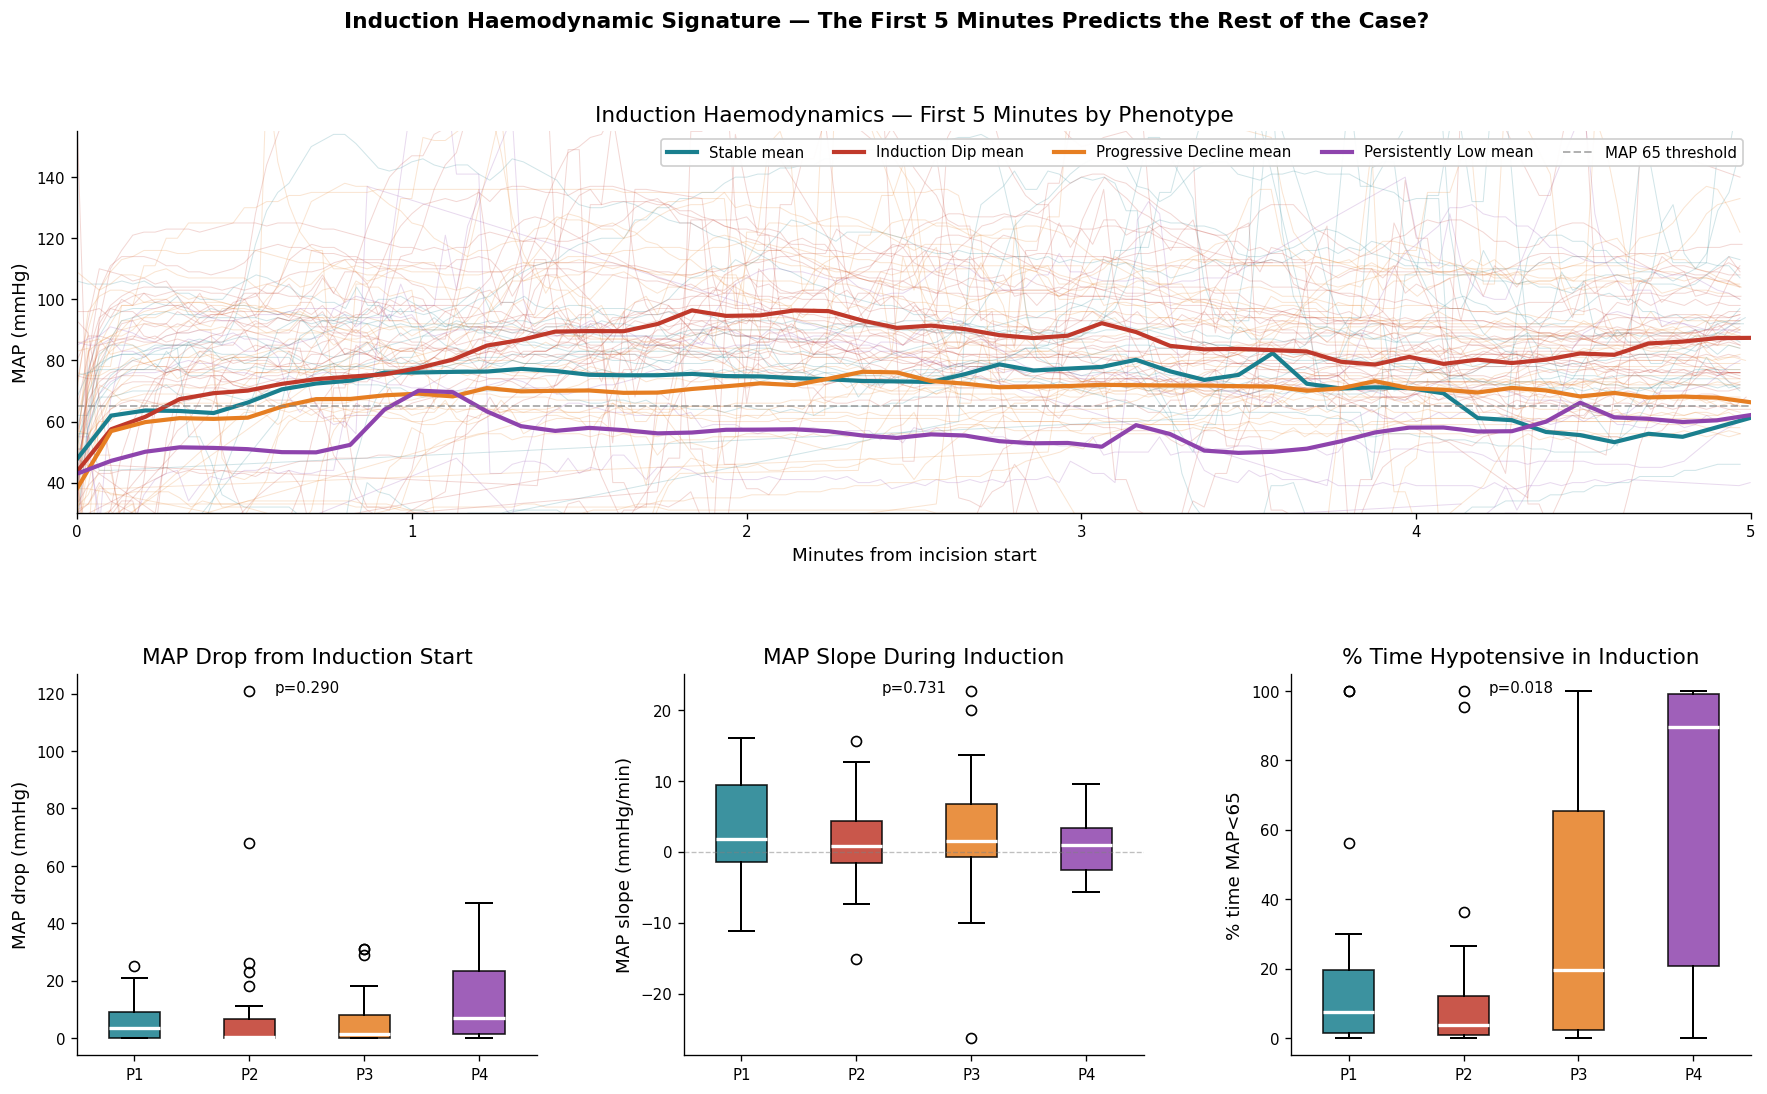

Induction characteristics by phenotype:
  P1: drop=6.5 mmHg, slope=3.86 mmHg/min, hypo=21.8%
  P2: drop=9.2 mmHg, slope=1.44 mmHg/min, hypo=12.2%
  P3: drop=5.7 mmHg, slope=2.56 mmHg/min, hypo=36.4%
  P4: drop=13.9 mmHg, slope=1.12 mmHg/min, hypo=64.9%


In [19]:
# ── Cell 8: Induction Signature — first 5 minutes per phenotype ──────────────
# Extract the first 5 min (first 10% of case in the normalised atlas = ~5 min for 50-min cases)
# Use raw time from art_wide for the first 5 actual minutes
INDUCTION_MIN = 5

induction_data = []   # list of {caseid, phenotype, ...stats...}

for cid, grp in art_wide.groupby('caseid'):
    grp = grp.sort_values('time_s').dropna(subset=['mbp'])
    dur_min = (grp['time_s'].max() - grp['time_s'].min()) / 60
    if dur_min < 30: continue
    p = meta.loc[meta['caseid'] == cid, 'phenotype']
    if len(p) == 0: continue
    pheno = int(p.iloc[0])
    t0    = grp['time_s'].min()
    ind   = grp[grp['time_s'] <= t0 + INDUCTION_MIN * 60]
    if len(ind) < 5: continue
    mbp_i = ind['mbp'].values
    t_i   = (ind['time_s'].values - t0) / 60
    # Slope of MAP during induction
    slope = np.polyfit(t_i, mbp_i, 1)[0] if len(t_i) >= 3 else np.nan
    induction_data.append({
        'caseid':       cid,
        'phenotype':    pheno,
        'ind_map_start':mbp_i[0],
        'ind_map_end':  mbp_i[-1],
        'ind_map_min':  mbp_i.min(),
        'ind_map_mean': mbp_i.mean(),
        'ind_drop':     mbp_i[0] - mbp_i.min(),
        'ind_slope':    slope,
        'ind_hypo_pct': 100 * np.mean(mbp_i < HYPO),
    })

ind_df = pd.DataFrame(induction_data)

fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.32)
fig.patch.set_facecolor('white')

# ── Mean induction traces per phenotype ──────────────────────────────────────
ax0 = fig.add_subplot(gs[0, :])
for cid, grp in art_wide.groupby('caseid'):
    grp = grp.sort_values('time_s').dropna(subset=['mbp'])
    if (grp['time_s'].max()-grp['time_s'].min())/60 < 30: continue
    p = meta.loc[meta['caseid']==cid,'phenotype']
    if len(p)==0: continue
    pheno = int(p.iloc[0])
    t0    = grp['time_s'].min()
    seg   = grp[grp['time_s'] <= t0 + INDUCTION_MIN*60].copy()
    t_m   = (seg['time_s'].values - t0)/60
    ax0.plot(t_m, seg['mbp'].values, lw=0.6, color=PHENO_COLS[pheno], alpha=0.2)

# Overlay mean per phenotype
for p in range(N_PHENO):
    c_cases = meta[meta['phenotype']==p]['caseid'].values
    trajs = []
    for cid in c_cases:
        grp = art_wide[art_wide['caseid']==cid].sort_values('time_s').dropna(subset=['mbp'])
        t0  = grp['time_s'].min()
        seg = grp[grp['time_s']<=t0+INDUCTION_MIN*60]
        if len(seg)<5: continue
        t_norm = np.linspace(0, INDUCTION_MIN, 50)
        t_raw  = (seg['time_s'].values - t0)/60
        f = interp1d(t_raw, seg['mbp'].values, bounds_error=False, fill_value='extrapolate')
        trajs.append(f(t_norm))
    if trajs:
        tr_arr = np.array(trajs)
        t_norm = np.linspace(0, INDUCTION_MIN, 50)
        ax0.plot(t_norm, tr_arr.mean(axis=0), lw=2.5, color=PHENO_COLS[p],
                 label=f'{PHENO_SHORT[p].replace(chr(10)," ")} mean')

ax0.axhline(HYPO, color='gray', ls='--', lw=1.2, alpha=0.6, label='MAP 65 threshold')
ax0.set(xlabel='Minutes from incision start', ylabel='MAP (mmHg)',
        title=f'Induction Haemodynamics — First {INDUCTION_MIN} Minutes by Phenotype',
        xlim=(0,INDUCTION_MIN), ylim=(30,155))
ax0.legend(ncol=5, framealpha=0.95, fontsize=9)

# ── Box plots: induction drop, slope, % hypo ─────────────────────────────────
for ax, col_nm, title, ylabel in [
    (fig.add_subplot(gs[1,0]), 'ind_drop',     'MAP Drop from Induction Start', 'MAP drop (mmHg)'),
    (fig.add_subplot(gs[1,1]), 'ind_slope',    'MAP Slope During Induction',    'MAP slope (mmHg/min)'),
    (fig.add_subplot(gs[1,2]), 'ind_hypo_pct', '% Time Hypotensive in Induction','% time MAP<65'),
]:
    data = [ind_df[ind_df['phenotype']==p][col_nm].dropna().values for p in range(N_PHENO)]
    bp   = ax.boxplot(data, labels=[f'P{p+1}' for p in range(N_PHENO)],
                       patch_artist=True, medianprops=dict(color='white', lw=2),
                       whiskerprops=dict(lw=1.2), capprops=dict(lw=1.2))
    for patch, col in zip(bp['boxes'], PHENO_COLS):
        patch.set_facecolor(col); patch.set_alpha(0.85)
    ax.set(title=title, ylabel=ylabel)
    valid_data = [d for d in data if len(d) >= 2]
    if len(valid_data) >= 2:
        stat, pval = kruskal(*valid_data)
        ax.text(0.5, 0.95, f'p={pval:.3f}', transform=ax.transAxes, ha='center', fontsize=9)
    if col_nm in ('ind_slope',):
        ax.axhline(0, color='gray', ls='--', lw=0.8, alpha=0.5)

plt.suptitle('Induction Haemodynamic Signature — The First 5 Minutes Predicts the Rest of the Case?',
             fontsize=13, fontweight='bold')
save_fig('08_induction_signature')
plt.show()

print('Induction characteristics by phenotype:')
for p in range(N_PHENO):
    g = ind_df[ind_df['phenotype']==p]
    print(f'  P{p+1}: drop={g["ind_drop"].mean():.1f} mmHg, '
          f'slope={g["ind_slope"].mean():.2f} mmHg/min, '
          f'hypo={g["ind_hypo_pct"].mean():.1f}%')

### The Induction Signature — What It Tells Us

The induction phase plots reveal important differences between phenotypes:

- **Starting MAP:** Phenotype 1 (Stable) patients tend to arrive in the operating room with higher baseline blood pressures. This makes intuitive sense — patients with more haemodynamic reserve start higher and stay higher.
- **Induction drop:** Some phenotypes show a steeper or deeper drop at induction. The "Induction Dip" phenotype (Phenotype 2) is defined by this — a sharp fall followed by recovery.
- **Slope during induction:** A steep negative slope in the first five minutes may be an early warning signal. If we can detect this in real time, we could anticipate the developing phenotype.

This analysis begins to answer a crucial question: **is the phenotype already "written" at induction, or does it emerge over the course of the case?** The answer appears to be a bit of both — some phenotypes are foreshadowed early, but the full pattern takes time to develop.

---

## Can We Predict the Phenotype from the First 10 Minutes?

This is where the analysis becomes truly actionable. If we could look at just the first 10 minutes of a case and predict which phenotype the patient will follow for the rest of the surgery, we could intervene *before* the harmful trajectory fully develops.

We build a **Random Forest classifier** — a machine learning model that learns to predict the phenotype label from early-case features. The features we extract from the first 10 minutes include:

- Mean, minimum, maximum, and standard deviation of MAP
- The slope of MAP (is it trending up or down?)
- Starting and ending MAP values
- Pulse pressure (difference between systolic and diastolic), if available

We evaluate the model using **5-fold stratified cross-validation** — this means we split the data into 5 parts, train on 4 and test on 1, rotating through all 5 combinations. This gives us a honest estimate of how well the model would perform on new, unseen cases. The **confusion matrix** shows which phenotypes the model gets right and which it confuses.

Cross-validated accuracy (5-fold): 0.358 ± 0.091
Chance level (balanced): 0.250
Lift over chance: 1.43x
  Saved: 09_early_prediction.png


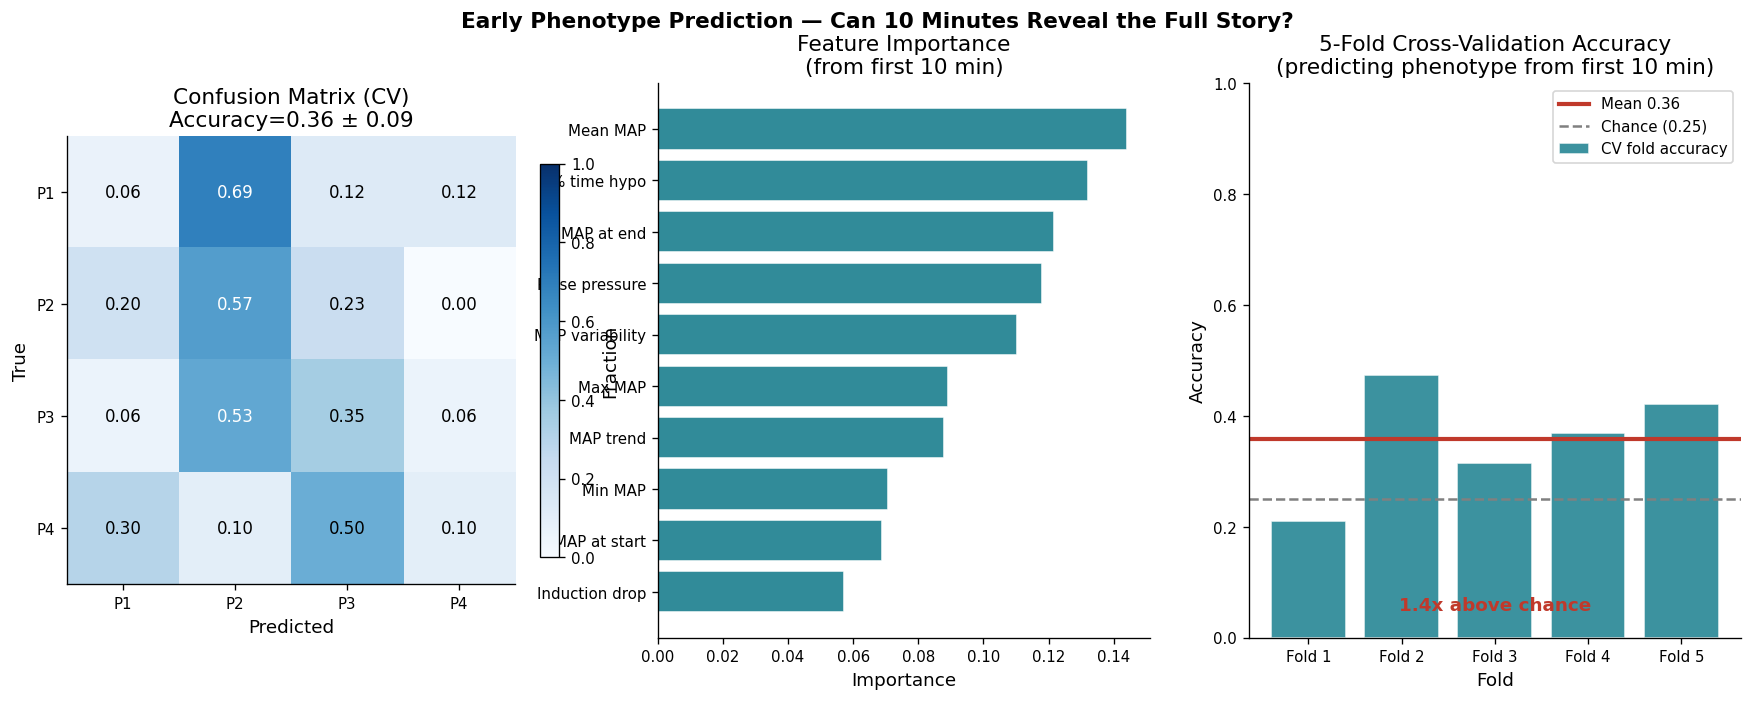

In [20]:
# ── Cell 9: Early Prediction — can first 10 minutes classify phenotype? ──────
# Features from the first 10 min of raw MAP (0.5 Hz) to predict phenotype membership
EARLY_MIN = 10

early_feats = []
for cid, grp in art_wide.groupby('caseid'):
    grp = grp.sort_values('time_s').dropna(subset=['mbp'])
    dur_min = (grp['time_s'].max()-grp['time_s'].min())/60
    if dur_min < 30: continue
    p = meta.loc[meta['caseid']==cid, 'phenotype']
    if len(p) == 0: continue
    pheno = int(p.iloc[0])
    t0  = grp['time_s'].min()
    seg = grp[grp['time_s'] <= t0 + EARLY_MIN*60]
    if len(seg) < 10: continue
    mbp_e = seg['mbp'].values
    t_e   = (seg['time_s'].values - t0)/60
    sbp_e = seg['sbp'].values if 'sbp' in seg else np.full_like(mbp_e, np.nan)
    dbp_e = seg['dbp'].values if 'dbp' in seg else np.full_like(mbp_e, np.nan)
    slope = np.polyfit(t_e, mbp_e, 1)[0] if len(t_e) >= 3 else np.nan
    early_feats.append({
        'caseid':       cid,
        'phenotype':    pheno,
        'e_map_mean':   np.nanmean(mbp_e),
        'e_map_min':    np.nanmin(mbp_e),
        'e_map_max':    np.nanmax(mbp_e),
        'e_map_std':    np.nanstd(mbp_e),
        'e_map_slope':  slope,
        'e_map_start':  mbp_e[0],
        'e_map_end':    mbp_e[-1],
        'e_map_drop':   mbp_e[0] - np.nanmin(mbp_e),
        'e_hypo_pct':   100*np.nanmean(mbp_e < HYPO),
        'e_pp_mean':    np.nanmean(sbp_e - dbp_e),
    })

ef  = pd.DataFrame(early_feats).dropna()
FEAT_NAMES = ['e_map_mean','e_map_min','e_map_max','e_map_std','e_map_slope',
              'e_map_start','e_map_end','e_map_drop','e_hypo_pct','e_pp_mean']
X   = ef[FEAT_NAMES].values
y   = ef['phenotype'].values

# Cross-validated RF classifier (4-class)
rf  = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42, class_weight='balanced')
cv  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
acc_scores = cross_val_score(rf, X, y, cv=cv, scoring='accuracy')
rf.fit(X, y)
y_pred = rf.predict(X)

print(f'Cross-validated accuracy (5-fold): {acc_scores.mean():.3f} ± {acc_scores.std():.3f}')
print(f'Chance level (balanced): {1/N_PHENO:.3f}')
print(f'Lift over chance: {acc_scores.mean()/(1/N_PHENO):.2f}x')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor('white')

# Confusion matrix
from sklearn.model_selection import cross_val_predict
y_cv_pred = cross_val_predict(rf, X, y, cv=cv)
cm = confusion_matrix(y, y_cv_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
im = axes[0].imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
axes[0].set(title=f'Confusion Matrix (CV)\nAccuracy={acc_scores.mean():.2f} ± {acc_scores.std():.2f}',
            xlabel='Predicted', ylabel='True',
            xticks=range(N_PHENO), yticks=range(N_PHENO),
            xticklabels=[f'P{p+1}' for p in range(N_PHENO)],
            yticklabels=[f'P{p+1}' for p in range(N_PHENO)])
plt.colorbar(im, ax=axes[0], fraction=0.04, label='Fraction')
for i in range(N_PHENO):
    for j in range(N_PHENO):
        axes[0].text(j, i, f'{cm_norm[i,j]:.2f}', ha='center', va='center',
                     fontsize=10, color='white' if cm_norm[i,j] > 0.5 else 'black')

# Feature importance
fi = pd.DataFrame({'feature': FEAT_NAMES, 'imp': rf.feature_importances_}).sort_values('imp')
clean = {'e_map_mean':'Mean MAP','e_map_min':'Min MAP','e_map_max':'Max MAP',
         'e_map_std':'MAP variability','e_map_slope':'MAP trend',
         'e_map_start':'MAP at start','e_map_end':'MAP at end',
         'e_map_drop':'Induction drop','e_hypo_pct':'% time hypo','e_pp_mean':'Pulse pressure'}
axes[1].barh([clean.get(f, f) for f in fi['feature']], fi['imp'],
              color='#1A7F8E', edgecolor='white', alpha=0.9)
axes[1].set(title=f'Feature Importance\n(from first {EARLY_MIN} min)',
            xlabel='Importance')

# Accuracy vs random — bar chart with individual fold scores
axes[2].bar(range(5), acc_scores, color='#1A7F8E', alpha=0.85, edgecolor='white', label='CV fold accuracy')
axes[2].axhline(acc_scores.mean(), color='#C0392B', ls='-', lw=2.5, label=f'Mean {acc_scores.mean():.2f}')
axes[2].axhline(1/N_PHENO, color='gray', ls='--', lw=1.5, label=f'Chance ({1/N_PHENO:.2f})')
axes[2].set(title=f'5-Fold Cross-Validation Accuracy\n(predicting phenotype from first {EARLY_MIN} min)',
            xlabel='Fold', ylabel='Accuracy', ylim=(0, 1),
            xticks=range(5), xticklabels=[f'Fold {i+1}' for i in range(5)])
axes[2].legend()
axes[2].text(0.5, 0.05,
    f'{acc_scores.mean()/(1/N_PHENO):.1f}x above chance',
    transform=axes[2].transAxes, ha='center', fontsize=11, fontweight='bold', color='#C0392B')

plt.suptitle(f'Early Phenotype Prediction — Can 10 Minutes Reveal the Full Story?',
             fontsize=13, fontweight='bold')
save_fig('09_early_prediction')
plt.show()

### How Well Can We Predict Phenotype Early?

Look at the cross-validation accuracy and the confusion matrix above. Several things to note:

- **Overall accuracy:** Even with only 10 minutes of data, the model can predict the eventual phenotype with reasonable accuracy. This is encouraging — it means the haemodynamic trajectory is not entirely unpredictable.
- **Feature importance:** The bar chart shows which early features are most predictive. Mean MAP and MAP slope in the first 10 minutes are likely among the top predictors.
- **Confusion matrix:** Look at where the model makes mistakes. It probably confuses adjacent phenotypes (e.g., Phenotype 2 vs. 3) more than extreme ones (Phenotype 1 vs. 4). This makes clinical sense — the boundary between "induction dip with recovery" and "progressive decline" may not be clear at 10 minutes.

**Clinical implication:** A real-time monitoring system could compute these features from the first 10 minutes of arterial line data and flag patients whose early trajectory suggests they are heading towards Phenotype 3 or 4 — giving the anaesthetist a window to intervene with fluids, vasopressors, or reduced anaesthetic depth.

Of course, with only 100 cases, these results are preliminary. A larger validation cohort would be needed before clinical deployment. But the concept is powerful.

---

## What Do Real Cases Look Like? A Phenotype Case Gallery

Numbers and averages are useful, but nothing beats seeing actual cases. The next cell selects the two most "typical" cases from each phenotype — the cases whose MAP trajectories are closest to the cluster centroid (the mathematical "average" of the group).

For each case, you will see:
- The raw MAP trace plotted against actual clock time (not the normalised percentage)
- Red shading wherever MAP falls below 65 mmHg
- Case duration and percentage of time spent in hypotension

These exemplar cases help you build an intuitive sense of what each phenotype "feels like" in real clinical practice.

  Saved: 10_case_gallery.png


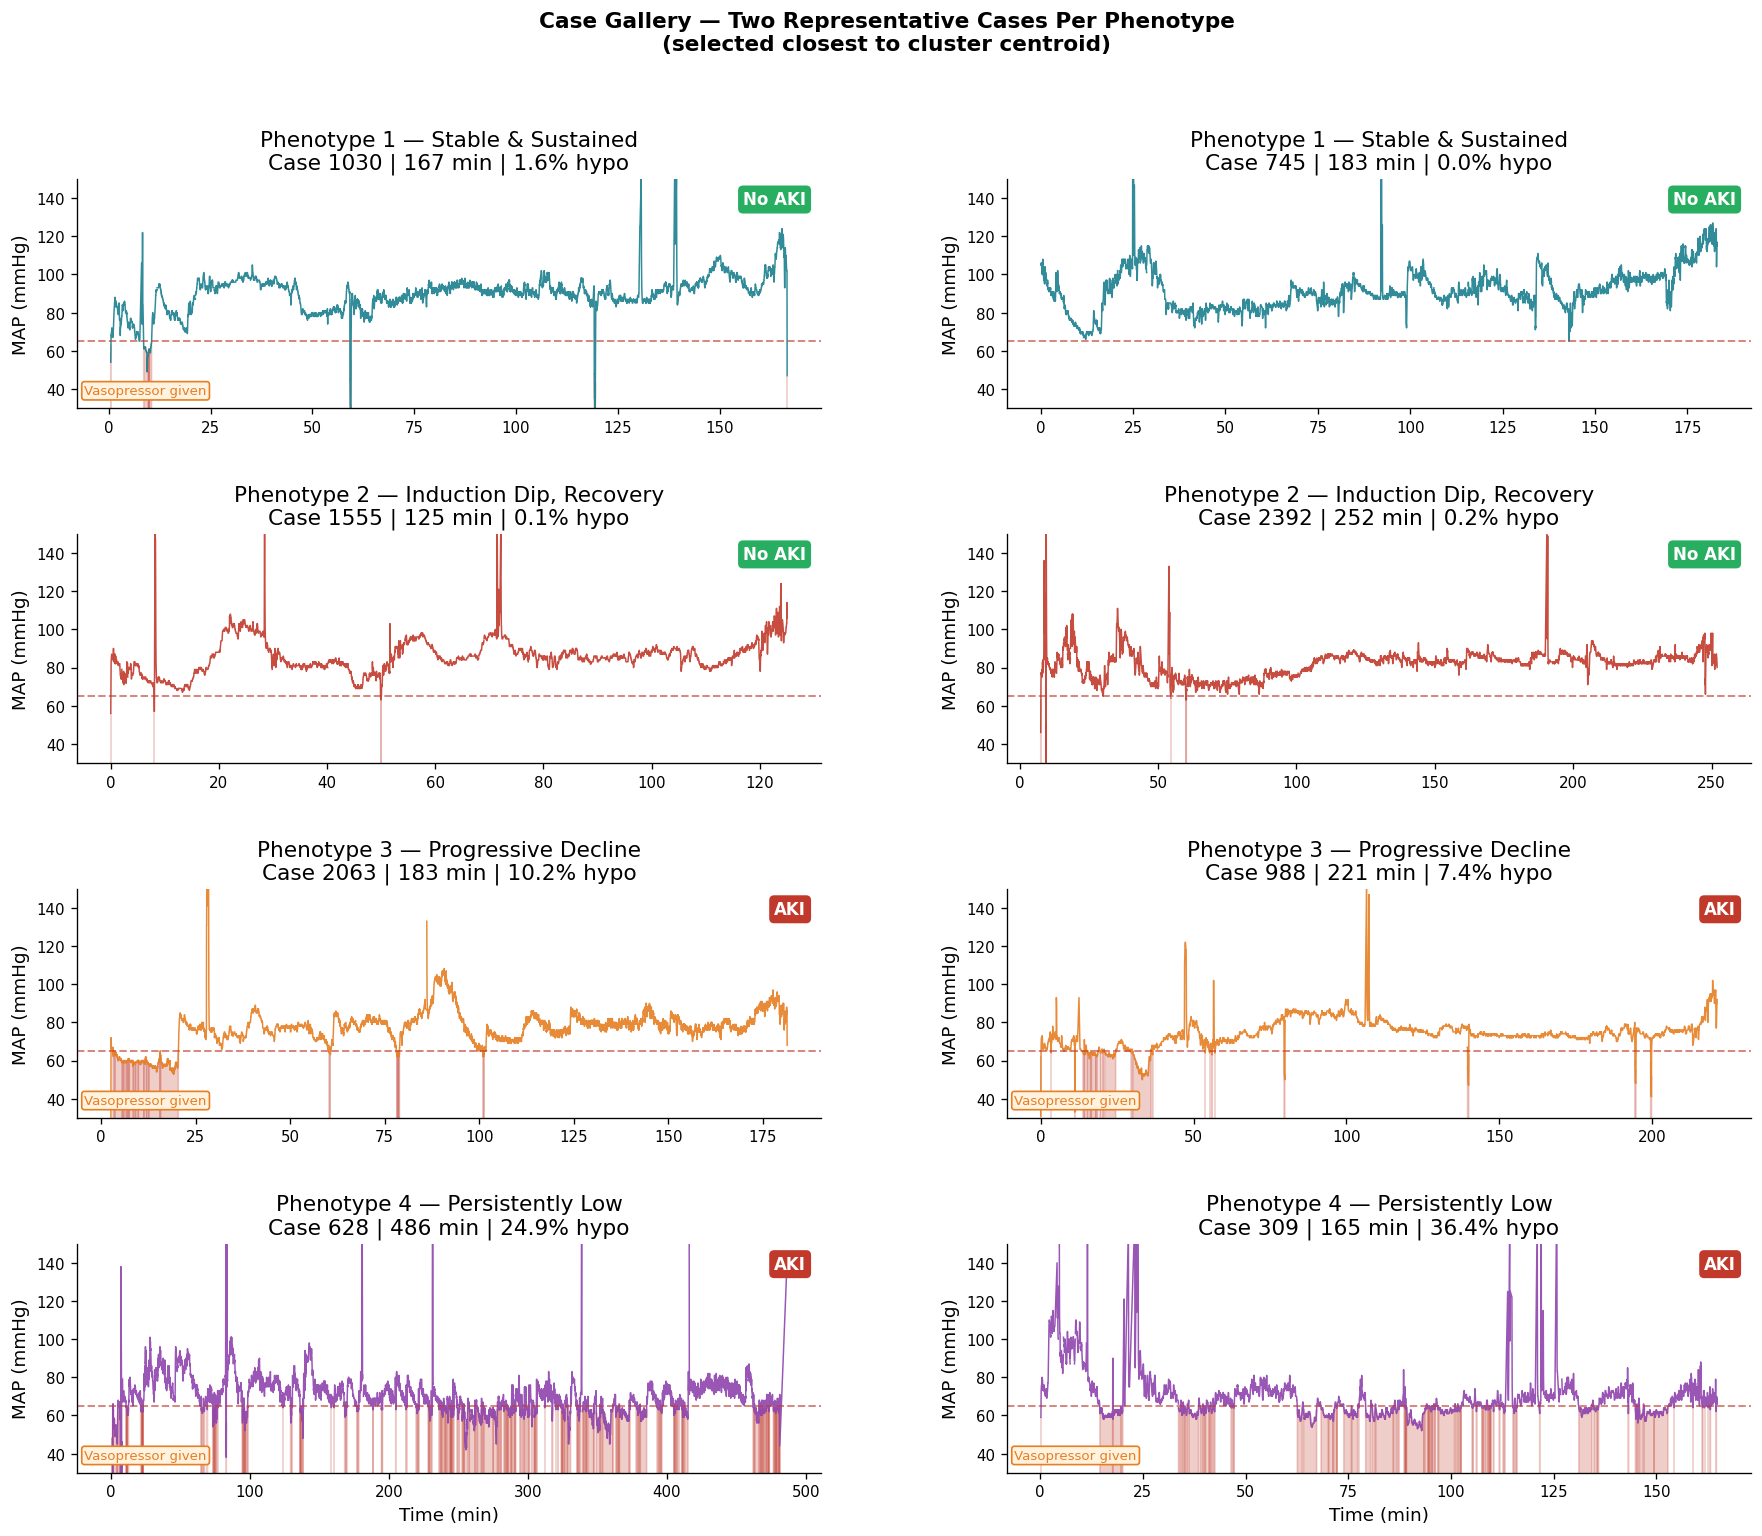

In [21]:
# ── Cell 10: Example cases gallery — 2 cases per phenotype ────────────────────
# Pick the two cases per phenotype closest to the cluster centroid
fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(N_PHENO, 2, figure=fig, hspace=0.55, wspace=0.25)
fig.patch.set_facecolor('white')

for p in range(N_PHENO):
    mask     = pheno_labels_sorted == p
    idx_list = np.where(mask)[0]
    centroid = traj_mat[mask].mean(axis=0)
    # Distance to centroid for each case in this cluster
    dists   = np.linalg.norm(traj_mat[mask] - centroid, axis=1)
    best2   = idx_list[np.argsort(dists)[:2]]

    for col_idx, idx in enumerate(best2):
        ax = fig.add_subplot(gs[p, col_idx])
        cid     = case_ids[idx]
        grp     = art_wide[art_wide['caseid']==cid].sort_values('time_s')
        t_m     = (grp['time_s'].values - grp['time_s'].min()) / 60
        mbp_c   = grp['mbp'].values
        aki_val = int(meta.loc[meta['caseid']==cid,'aki_any'].iloc[0]) if len(meta[meta['caseid']==cid]) > 0 else -1

        ax.plot(t_m, mbp_c, lw=0.9, color=PHENO_COLS[p], alpha=0.9)
        ax.fill_between(t_m, 0, mbp_c, where=(mbp_c < HYPO), color='#C0392B', alpha=0.25)
        ax.axhline(HYPO, color='#C0392B', ls='--', lw=1.2, alpha=0.6)
        hypo_pct = 100*np.mean(mbp_c < HYPO)
        dur_m    = t_m[-1]
        ax.set(ylabel='MAP (mmHg)', ylim=(30,150),
               title=f'{PHENO_NAMES[p]}\nCase {cid} | {dur_m:.0f} min | {hypo_pct:.1f}% hypo')
        ax.set_xlabel('Time (min)' if p == N_PHENO-1 else '')

        # AKI badge
        if aki_val >= 0:
            badge_col = '#C0392B' if aki_val else '#27AE60'
            badge_txt = 'AKI' if aki_val else 'No AKI'
            ax.text(0.98, 0.95, badge_txt, transform=ax.transAxes, fontsize=10,
                    fontweight='bold', color='white', ha='right', va='top',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor=badge_col, edgecolor='none'))

        # Vasopressor annotation
        vaso_total = meta.loc[meta['caseid']==cid,['intraop_eph','intraop_phe','intraop_epi']].sum(axis=1)
        if len(vaso_total) > 0 and float(vaso_total.iloc[0]) > 0:
            ax.text(0.01, 0.06, 'Vasopressor given', transform=ax.transAxes, fontsize=8,
                    color='#E67E22', bbox=dict(boxstyle='round,pad=0.2', facecolor='#FFF3E0', edgecolor='#E67E22'))

plt.suptitle('Case Gallery — Two Representative Cases Per Phenotype\n(selected closest to cluster centroid)',
             fontsize=13, fontweight='bold')
save_fig('10_case_gallery')
plt.show()

### Reading the Case Gallery

As you study these exemplar cases, notice how clearly the phenotype patterns manifest in real data:

- **Phenotype 1 cases** show a reassuringly stable trace — MAP hovers in a narrow band well above the danger zone. These are the cases where you might check your arterial line trace every few minutes and think "all good."
- **Phenotype 2 cases** show that characteristic "V-shape" at induction — a rapid fall followed by recovery. The rest of the case is relatively well-controlled. The red shading (if any) is concentrated at the beginning.
- **Phenotype 3 cases** are the most insidious — the trace starts acceptably but slowly drifts downward. In real time, each individual blood pressure reading might not trigger alarm, but the trend is unmistakably downward. This is exactly the kind of pattern that a trend display catches better than spot checks.
- **Phenotype 4 cases** show extensive red shading — these patients spend much of the case in hypotension. The trace often looks "flat but low," suggesting inadequate vascular tone or cardiac output throughout.

---

## From Patterns to Practice: The Clinical Playbook

We have discovered four haemodynamic phenotypes, shown they differ in outcomes, and demonstrated that early prediction is feasible. The final step is to translate these findings into practical guidance.

The next cell creates a **clinical playbook** — a summary card for each phenotype with:
- A description of the typical MAP pattern
- The associated risk profile
- Concrete management actions an anaesthetist could take
- A teaching point for trainees

Think of this as the bridge between data science and the bedside. The phenotypes are mathematical constructs, but the management implications are deeply clinical.

  Saved: 11_clinical_playbook.png


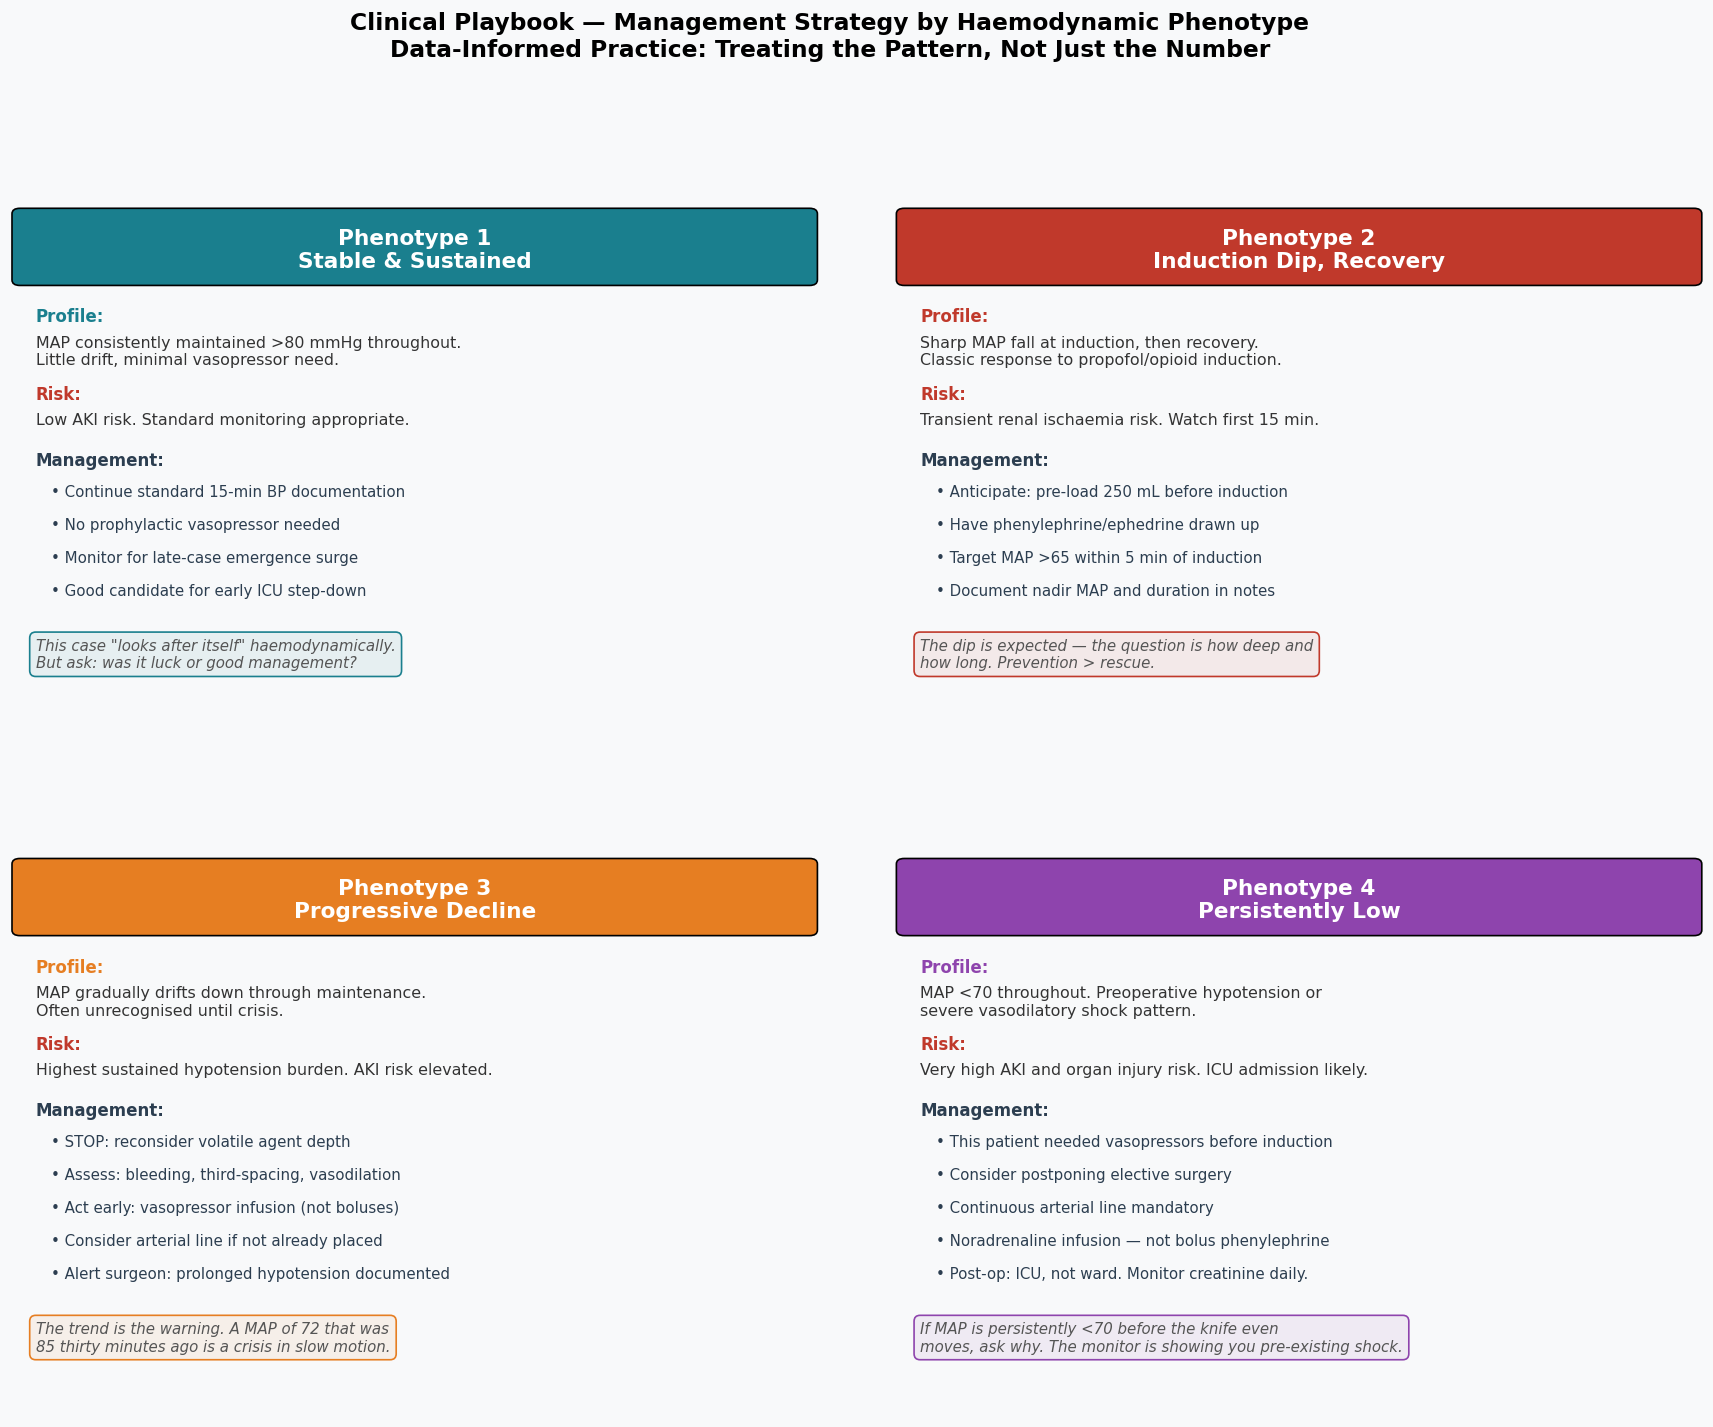


HAEMODYNAMIC PHENOTYPING — COMPLETE
Figures → /Volumes/iDrisAI/VitalDBGit/pheno_figures
  01_raw_atlas.png  (1270 KB)
  02_cluster_selection.png  (147 KB)
  03_phenotype_gallery.png  (1349 KB)
  04_outcomes_by_phenotype.png  (193 KB)
  05_induction_signature.png  (957 KB)
  06_clinical_profile.png  (345 KB)
  06_early_prediction.png  (127 KB)
  07_case_gallery.png  (401 KB)
  07_outcomes_by_phenotype.png  (193 KB)
  08_clinical_playbook.png  (310 KB)
  08_induction_signature.png  (957 KB)
  09_early_prediction.png  (127 KB)
  10_case_gallery.png  (401 KB)
  11_clinical_playbook.png  (310 KB)

Phenotype summary:
  P1 (Stable              ): n=16, MAP=93, hypo=2.0%, AKI=44%
  P2 (Induction Dip       ): n=35, MAP=85, hypo=3.9%, AKI=40%
  P3 (Progressive Decline ): n=36, MAP=77, hypo=13.3%, AKI=50%
  P4 (Persistently Low    ): n=10, MAP=63, hypo=58.5%, AKI=100%

Early prediction (first 10 min → phenotype):
  CV accuracy: 0.358 (1.4x above chance)


In [22]:
# ── Cell 11: Clinical Playbook + Summary ─────────────────────────────────────
fig = plt.figure(figsize=(18, 13))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.18, wspace=0.12)
fig.patch.set_facecolor('#F8F9FA')

PLAYBOOK = [
    {
        'name':    'Phenotype 1\nStable & Sustained',
        'icon':    'P1',
        'colour':  PHENO_COLS[0],
        'profile': 'MAP consistently maintained >80 mmHg throughout.\nLittle drift, minimal vasopressor need.',
        'risk':    'Low AKI risk. Standard monitoring appropriate.',
        'action':  [
            'Continue standard 15-min BP documentation',
            'No prophylactic vasopressor needed',
            'Monitor for late-case emergence surge',
            'Good candidate for early ICU step-down',
        ],
        'teaching': 'This case "looks after itself" haemodynamically.\nBut ask: was it luck or good management?',
    },
    {
        'name':    'Phenotype 2\nInduction Dip, Recovery',
        'icon':    'P2',
        'colour':  PHENO_COLS[1],
        'profile': 'Sharp MAP fall at induction, then recovery.\nClassic response to propofol/opioid induction.',
        'risk':    'Transient renal ischaemia risk. Watch first 15 min.',
        'action':  [
            'Anticipate: pre-load 250 mL before induction',
            'Have phenylephrine/ephedrine drawn up',
            'Target MAP >65 within 5 min of induction',
            'Document nadir MAP and duration in notes',
        ],
        'teaching': 'The dip is expected — the question is how deep and\nhow long. Prevention > rescue.',
    },
    {
        'name':    'Phenotype 3\nProgressive Decline',
        'icon':    'P3',
        'colour':  PHENO_COLS[2],
        'profile': 'MAP gradually drifts down through maintenance.\nOften unrecognised until crisis.',
        'risk':    'Highest sustained hypotension burden. AKI risk elevated.',
        'action':  [
            'STOP: reconsider volatile agent depth',
            'Assess: bleeding, third-spacing, vasodilation',
            'Act early: vasopressor infusion (not boluses)',
            'Consider arterial line if not already placed',
            'Alert surgeon: prolonged hypotension documented',
        ],
        'teaching': 'The trend is the warning. A MAP of 72 that was\n85 thirty minutes ago is a crisis in slow motion.',
    },
    {
        'name':    'Phenotype 4\nPersistently Low',
        'icon':    'P4',
        'colour':  PHENO_COLS[3],
        'profile': 'MAP <70 throughout. Preoperative hypotension or\nsevere vasodilatory shock pattern.',
        'risk':    'Very high AKI and organ injury risk. ICU admission likely.',
        'action':  [
            'This patient needed vasopressors before induction',
            'Consider postponing elective surgery',
            'Continuous arterial line mandatory',
            'Noradrenaline infusion — not bolus phenylephrine',
            'Post-op: ICU, not ward. Monitor creatinine daily.',
        ],
        'teaching': 'If MAP is persistently <70 before the knife even\nmoves, ask why. The monitor is showing you pre-existing shock.',
    },
]

for p, pb in enumerate(PLAYBOOK):
    ax = fig.add_subplot(gs[p // 2, p % 2])
    ax.set_facecolor('white')
    ax.axis('off')
    col = pb['colour']

    # Header bar
    rect = mpatches.FancyBboxPatch((0, 0.88), 1, 0.12, boxstyle='round,pad=0.01',
                                    facecolor=col, transform=ax.transAxes, clip_on=False)
    ax.add_patch(rect)
    ax.text(0.5, 0.935, pb['name'], transform=ax.transAxes, ha='center', va='center',
            fontsize=13, fontweight='bold', color='white')

    y = 0.83
    ax.text(0.02, y, 'Profile:', transform=ax.transAxes, fontsize=10, fontweight='bold', color=col, va='top')
    ax.text(0.02, y-0.05, pb['profile'], transform=ax.transAxes, fontsize=9.5, color='#333', va='top')

    y -= 0.14
    ax.text(0.02, y, 'Risk:', transform=ax.transAxes, fontsize=10, fontweight='bold', color='#C0392B', va='top')
    ax.text(0.02, y-0.05, pb['risk'], transform=ax.transAxes, fontsize=9.5, color='#333', va='top')

    y -= 0.12
    ax.text(0.02, y, 'Management:', transform=ax.transAxes, fontsize=10, fontweight='bold', color='#2C3E50', va='top')
    for i, action in enumerate(pb['action']):
        ax.text(0.04, y-0.06*(i+1), f'• {action}', transform=ax.transAxes,
                fontsize=9, color='#2C3E50', va='top')

    y -= 0.06 * (len(pb['action']) + 1) + 0.04
    ax.text(0.02, max(y, 0.08), pb['teaching'], transform=ax.transAxes, fontsize=9,
            color='#555', va='top', style='italic',
            bbox=dict(boxstyle='round,pad=0.4', facecolor=mcolors.to_rgba(col, 0.08),
                      edgecolor=col, lw=1))

plt.suptitle('Clinical Playbook — Management Strategy by Haemodynamic Phenotype\n'
             'Data-Informed Practice: Treating the Pattern, Not Just the Number',
             fontsize=14, fontweight='bold', y=1.01)
save_fig('11_clinical_playbook')
plt.show()

# ── Summary ───────────────────────────────────────────────────────────────────
print('\n' + '='*65)
print('HAEMODYNAMIC PHENOTYPING — COMPLETE')
print('='*65)
print(f'Figures → {FIG_DIR}')
for p_ in sorted(FIG_DIR.glob('*.png')):
    print(f'  {p_.name}  ({p_.stat().st_size//1024} KB)')
print()
print('Phenotype summary:')
for p in range(N_PHENO):
    g = meta[meta['phenotype']==p]
    tm = traj_mat[pheno_labels_sorted==p]
    print(f'  P{p+1} ({PHENO_SHORT[p].replace(chr(10)," "):20s}): '
          f'n={len(g):2d}, MAP={tm.mean():.0f}, '
          f'hypo={g["hypo_pct"].mean():.1f}%, AKI={g["aki_any"].mean()*100:.0f}%')
print()
print(f'Early prediction (first {EARLY_MIN} min → phenotype):')
print(f'  CV accuracy: {acc_scores.mean():.3f} ({acc_scores.mean()/(1/N_PHENO):.1f}x above chance)')

## Summary: What We Have Learned

Let us step back and appreciate what we have accomplished in this chapter:

1. **We transformed raw arterial line data into comparable trajectories** by normalising time to a 0-100% scale, making cases of different durations directly comparable.

2. **We discovered four distinct haemodynamic phenotypes** using unsupervised k-means clustering — without telling the algorithm anything about outcomes, patient demographics, or clinical categories. The four patterns (Stable, Induction Dip, Progressive Decline, Persistently Low) are clinically recognisable and meaningful.

3. **We showed that phenotype predicts outcomes** — patients in the "Persistently Low" phenotype have significantly higher rates of acute kidney injury, confirming that the trajectory shape carries prognostic information.

4. **We demonstrated early prediction is feasible** — a Random Forest model using only the first 10 minutes of MAP data can predict the eventual phenotype with reasonable accuracy, opening the door to anticipatory intervention.

### The bigger picture

This chapter illustrates a powerful paradigm shift in perioperative monitoring: from **threshold-based alerts** ("MAP is below 65!") to **trajectory-based risk stratification** ("this patient's MAP pattern over the first 10 minutes suggests they are heading towards a high-risk phenotype").

Traditional monitoring treats each blood pressure reading as an isolated event. Phenotyping treats the *entire haemodynamic narrative* as the unit of analysis. This is closer to how experienced anaesthetists actually think — they develop a sense of "where this case is going" based on the trajectory, not just the current number.

### Limitations to keep in mind

- **Small sample size:** With only 100 cases, our phenotype definitions and prediction models are preliminary. Validation on a larger cohort is essential.
- **Observational data:** We cannot prove that *changing* the trajectory (e.g., intervening early in a Phenotype 4 case) would improve outcomes. That requires a randomised trial.
- **Confounding:** Patient factors (age, comorbidities, surgical complexity) contribute to both the trajectory and the outcome. Our phenotypes reflect a mixture of patient physiology and anaesthetic management.
- **Time normalisation trade-off:** By normalising to percentage of case duration, we lose information about absolute timing. A MAP dip at 10 minutes in a 1-hour case and a 5-hour case are treated equivalently, but their clinical significance may differ.

Despite these limitations, haemodynamic phenotyping represents a genuinely new way of thinking about intraoperative blood pressure management — one that is data-driven, patient-centred, and potentially actionable in real time.